# 🚛 Fleet Maintenance Cost Prediction
## A Data Science Project on Logistics Operations Data

---

### 👤 Project Information
| Field | Detail |
|---|---|
| **Project Type** | Exploratory Data Analysis + Machine Learning |
| **Domain** | Transportation & Logistics |
| **Database** | SQLite — `logistics.db` |
| **Data Period** | January 2022 — December 2024 |
| **Fleet Size** | 120 trucks, 92 with full utilization records |
| **Total Tables** | 14 interconnected CSV files |

---

### 🎯 Project Objective

This project analyzes a logistics fleet database to identify the key
drivers of truck maintenance costs and build a predictive model that
classifies trucks as **Deteriorating** or **Stable/Improving** based
on their cost trajectory over time.

The ultimate goal is to demonstrate a complete, end-to-end data science
workflow — from raw SQL exploration through feature engineering to
machine learning — using a realistic transportation operations dataset.

---

### 📦 Dataset Overview

| Table | Description | Key Columns |
|---|---|---|
| `trucks` | Fleet inventory | make, model_year, status |
| `maintenance_records` | All repair events | total_cost, maintenance_type, downtime_hours |
| `truck_utilization_metrics` | Monthly performance | utilization_rate, maintenance_cost |
| `trips` | Individual trip logs | average_mpg, actual_distance_miles |
| `drivers` | Driver roster | employment_status, years_experience |
| `loads` | Cargo records | revenue, weight_lbs |
| `routes` | Route definitions | origin_city, destination_city |
| `customers` | Customer profiles | customer_type, customer_name |

---

### 🗺️ Project Phases

| Phase | Status | Description |
|---|---|---|
| **Phase 1** | ✅ Complete | SQL Exploration & EDA — 5 Focused Challenges |
| **Phase 2** | 🔄 In Progress | Data Preparation & Feature Engineering |
| **Phase 3** | ⏳ Pending | ML Modelling — Classification & Regression |
| **Phase 4** | ⏳ Pending | Results, Interpretation & Business Insights |

---

### 🔧 Why Option B — Fleet Maintenance Prediction?

After initial exploration of the dataset three project directions were
considered. Fleet Maintenance Cost Prediction was selected because:

- It has a **clear, well-defined target variable** (`cost_trajectory`)
- The data contains strong **predictor features** already present
- It is a **real industry problem** — predictive maintenance is widely
  used in transport, manufacturing and logistics
- It demonstrates the **full ML pipeline** — SQL → EDA → features → model

---

In [2]:
import os
print(os.listdir())


['.ipynb_checkpoints', '01_data_setup.ipynb', '02_data_setup.ipynb', 'charts', 'fleet_maintenance_phase1.ipynb', 'fleet_maintenance_project_handoff.md', 'Git Hub', 'LO', 'logistics.db', 'Logistics_Database_Schema.pdf', 'logistics_schema.txt', 'Plan.ipynb', 'Tables in database.docx', 'Table_Statistics_Summary.docx', 'Table_Statistics_Summary.pdf', '~$ Rodrigues Approach vs.docx', '~WRL0096.tmp', '🔍 Rodrigues Approach vs.docx', '🚚 Logistics SQL Learning Project Guide.docx']


In [3]:
import os
from pathlib import Path

# Check current working directory
print("Current working directory:")
print(os.getcwd())
print("\n" + "="*60)

# Check if HR folder exists
print("\nChecking folder structure...")
print("="*60)

# Try different possible paths
possible_paths = [
    "LO",

]

for path in possible_paths:
    if os.path.exists(path):
        print(f"\n✓ FOUND: {path}")
        print(f"Contents:")
        for item in os.listdir(path):
            item_path = os.path.join(path, item)
            if os.path.isfile(item_path):
                size_mb = os.path.getsize(item_path) / (1024 * 1024)
                print(f"  📄 {item} ({size_mb:.2f} MB)")
            else:
                print(f"  📁 {item}/")
    else:
        print(f"\n✗ NOT FOUND: {path}")

# List everything in current directory
print("\n" + "="*60)
print("All items in current directory:")
print("="*60)
for item in os.listdir('.'):
    if os.path.isdir(item):
        print(f"  📁 {item}/")
    else:
        print(f"  📄 {item}")

Current working directory:
C:\Users\ADMIN\Desktop\Logistics Operations Database


Checking folder structure...

✓ FOUND: LO
Contents:
  📄 customers.csv (0.01 MB)
  📄 DATABASE_SCHEMA.txt (0.00 MB)
  📄 delivery_events.csv (21.21 MB)
  📄 drivers.csv (0.01 MB)
  📄 driver_monthly_metrics.csv (0.25 MB)
  📄 facilities.csv (0.00 MB)
  📄 fuel_purchases.csv (19.43 MB)
  📄 loads.csv (8.00 MB)
  📄 maintenance_records.csv (0.30 MB)
  📄 routes.csv (0.00 MB)
  📄 safety_incidents.csv (0.03 MB)
  📄 trailers.csv (0.01 MB)
  📄 trips.csv (7.97 MB)
  📄 trucks.csv (0.01 MB)
  📄 truck_utilization_metrics.csv (0.19 MB)

All items in current directory:
  📁 .ipynb_checkpoints/
  📄 01_data_setup.ipynb
  📄 02_data_setup.ipynb
  📁 charts/
  📄 fleet_maintenance_phase1.ipynb
  📄 fleet_maintenance_project_handoff.md
  📁 Git Hub/
  📁 LO/
  📄 logistics.db
  📄 Logistics_Database_Schema.pdf
  📄 logistics_schema.txt
  📄 Plan.ipynb
  📄 Tables in database.docx
  📄 Table_Statistics_Summary.docx
  📄 Table_Statistics_Summary.p

In [4]:
import sqlite3
import pandas as pd
from pathlib import Path

class LogisticsDatasetLoader:
    def __init__(self, data_folder, db_name='logistics.db'):
        self.data_folder = Path(data_folder)
        self.db_name = db_name
        self.conn = None
        
        # Logistics dataset file mappings
        self.file_mappings = {
            'customers': 'customers.csv',
            'delivery_events': 'delivery_events.csv',
            'drivers': 'drivers.csv',
            'driver_monthly_metrics': 'driver_monthly_metrics.csv',
            'facilities': 'facilities.csv',
            'fuel_purchases': 'fuel_purchases.csv',
            'loads': 'loads.csv',
            'maintenance_records': 'maintenance_records.csv',
            'routes': 'routes.csv',
            'safety_incidents': 'safety_incidents.csv',
            'trailers': 'trailers.csv',
            'trips': 'trips.csv',
            'trucks': 'trucks.csv',
            'truck_utilization_metrics': 'truck_utilization_metrics.csv'
        }
    
    def connect_db(self):
        """Connect to SQLite database"""
        self.conn = sqlite3.connect(self.db_name)
        print(f"✓ Connected to database: {self.db_name}")
    
    def list_available_files(self):
        """Check which CSV files exist in data folder"""
        print("\nChecking available Logistics dataset files...")
        print("="*70)
        for key, filename in self.file_mappings.items():
            filepath = self.data_folder / filename
            status = '✓' if filepath.exists() else '✗ MISSING:'
            print(f"{status} {filename}")
    
    def preview_file(self, file_key, rows=5):
        """Preview first N rows of a CSV file"""
        filename = self.file_mappings.get(file_key)
        filepath = self.data_folder / filename
        df = pd.read_csv(filepath, nrows=rows)
        print(f"\nPreview: {file_key.upper()} (First {rows} rows)")
        print("="*70)
        print(df)
        return df
    
    def load_all_to_db(self):
        """Load all CSV files into SQLite database"""
        self.connect_db()
        for table, filename in self.file_mappings.items():
            filepath = self.data_folder / filename
            print(f"Loading {filename} → TABLE: {table}")
            df = pd.read_csv(filepath)
            df.to_sql(table, self.conn, if_exists='replace', index=False)
        print("\n✓ All Logistics tables loaded successfully!")
    
    def list_all_tables(self):
        """List all tables in database"""
        cursor = self.conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
        tables = cursor.fetchall()
        print("\nTables in database:")
        print("="*70)
        for t in tables:
            print(f"  • {t[0]}")
    
    def show_table_info(self, table):
        """Show structure of a single table"""
        query = f"PRAGMA table_info({table})"
        df = pd.read_sql_query(query, self.conn)
        print(f"\n{'='*70}")
        print(f"Table Structure: {table.upper()}")
        print(f"{'='*70}")
        print(df)
        print(f"Total columns: {len(df)}\n")
    
    def show_all_table_info(self, detailed=True):
        """Show structure for ALL tables in database"""
        cursor = self.conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
        tables = cursor.fetchall()
        
        print("\n" + "="*70)
        print("DATABASE SCHEMA - ALL TABLES")
        print("="*70)
        
        for table in tables:
            table_name = table[0]
            query = f"PRAGMA table_info({table_name})"
            df = pd.read_sql_query(query, self.conn)
            
            if detailed:
                print(f"\n{'='*70}")
                print(f"📋 TABLE: {table_name.upper()}")
                print(f"{'='*70}")
                print(df)
                print(f"Total columns: {len(df)}")
            else:
                # Compact view
                columns = df['name'].tolist()
                print(f"\n📋 {table_name.upper()} ({len(df)} columns)")
                print(f"   Columns: {', '.join(columns)}")
        
        print(f"\n{'='*70}")
        print(f"Total tables: {len(tables)}")
        print("="*70)
    
    def get_table_stats(self):
        """Get row counts for all tables"""
        cursor = self.conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
        tables = cursor.fetchall()
        
        print("\n" + "="*70)
        print("TABLE STATISTICS")
        print("="*70)
        
        stats = []
        for table in tables:
            table_name = table[0]
            count_query = f"SELECT COUNT(*) FROM {table_name}"
            cursor.execute(count_query)
            row_count = cursor.fetchone()[0]
            stats.append({'Table': table_name, 'Row Count': f"{row_count:,}"})
        
        stats_df = pd.DataFrame(stats)
        print(stats_df.to_string(index=False))
        print(f"\n{'='*70}")
    
    def get_table_sample(self, table_name, n=5):
        """Get sample rows from a table"""
        query = f"SELECT * FROM {table_name} LIMIT {n}"
        df = pd.read_sql_query(query, self.conn)
        print(f"\n{'='*70}")
        print(f"Sample Data: {table_name.upper()} (First {n} rows)")
        print(f"{'='*70}")
        print(df)
        return df
    
    def export_schema_to_file(self, output_file='database_schema.txt'):
        """Export complete schema to text file"""
        cursor = self.conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
        tables = cursor.fetchall()
        
        with open(output_file, 'w') as f:
            f.write("="*70 + "\n")
            f.write("LOGISTICS DATABASE SCHEMA\n")
            f.write("="*70 + "\n\n")
            
            for table in tables:
                table_name = table[0]
                query = f"PRAGMA table_info({table_name})"
                df = pd.read_sql_query(query, self.conn)
                
                f.write(f"\n{'='*70}\n")
                f.write(f"TABLE: {table_name.upper()}\n")
                f.write(f"{'='*70}\n")
                f.write(df.to_string(index=False))
                f.write(f"\n\nTotal columns: {len(df)}\n")
                
                # Get row count
                cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
                row_count = cursor.fetchone()[0]
                f.write(f"Total rows: {row_count:,}\n")
        
        print(f"\n✓ Schema exported to: {output_file}")
    
    def close(self):
        """Close database connection"""
        if self.conn:
            self.conn.close()
            print("\n✓ Connection closed")


# ------------------ EXECUTION ------------------
if __name__ == "__main__":
    
    loader = LogisticsDatasetLoader(r"LO")
    
    # Step 1: Check available files
    loader.list_available_files()
    
    # Step 2: Preview a sample file
    loader.preview_file('loads')
    
    # Step 3: Load all data into database
    loader.load_all_to_db()
    
    # Step 4: List all tables
    loader.list_all_tables()
    
    # ============================================
    # NEW: Show ALL table structures at once
    # ============================================
    
    # Option A: Detailed view (full table info for each table)
    loader.show_all_table_info(detailed=True)
    
    # Option B: Compact view (just column names)
    # loader.show_all_table_info(detailed=False)
    
    # Option C: Get row counts for all tables
    loader.get_table_stats()
    
    # Option D: Export schema to text file
    loader.export_schema_to_file('logistics_schema.txt')
    
    # Option E: Show single table (your original way)
    # loader.show_table_info('drivers')
    
    # Option F: Get sample data from specific table
    # loader.get_table_sample('trips', n=10)
    
    loader.close()
    
    print("\n🚚 Logistics DB Setup Complete! You can now run SQL queries!")


Checking available Logistics dataset files...
✓ customers.csv
✓ delivery_events.csv
✓ drivers.csv
✓ driver_monthly_metrics.csv
✓ facilities.csv
✓ fuel_purchases.csv
✓ loads.csv
✓ maintenance_records.csv
✓ routes.csv
✓ safety_incidents.csv
✓ trailers.csv
✓ trips.csv
✓ trucks.csv
✓ truck_utilization_metrics.csv

Preview: LOADS (First 5 rows)
        load_id customer_id  route_id   load_date     load_type  weight_lbs  \
0  LOAD00000001   CUST00183  RTE00019  2022-01-01       Dry Van       19178   
1  LOAD00000002   CUST00076  RTE00058  2022-01-01       Dry Van       27761   
2  LOAD00000003   CUST00027  RTE00048  2022-01-01  Refrigerated       35594   
3  LOAD00000004   CUST00088  RTE00013  2022-01-01  Refrigerated       33274   
4  LOAD00000005   CUST00185  RTE00020  2022-01-01       Dry Van       40257   

   pieces  revenue  fuel_surcharge  accessorial_charges load_status  \
0      13  3045.23          406.72                  100   Completed   
1      22  1224.48           98.61      

In [5]:
# ============================================================================
# LOGISTICS DATASET: SQL Exploration & Analysis
# ============================================================================
# Objective: Practice SQL queries and perform EDA on Transportation Logistics Data
# Dataset: Logistics Operations (Drivers, Trips, Loads, Trucks, Fuel, etc.)
# Database: logistics.db
# ============================================================================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("LOGISTICS SQL EXPLORATION & ANALYSIS")
print("="*70)

# ============================================================================
# SECTION 1: DATABASE CONNECTION & VERIFICATION
# ============================================================================

# Connect to database created from CSV files
conn = sqlite3.connect('logistics.db')
cursor = conn.cursor()

print("\n✓ Connected to database: logistics.db\n")

# View all available tables
print("="*70)
print("AVAILABLE TABLES:")
print("="*70)
tables_query = "SELECT name FROM sqlite_master WHERE type='table'"
tables = pd.read_sql(tables_query, conn)
print(tables)


LOGISTICS SQL EXPLORATION & ANALYSIS

✓ Connected to database: logistics.db

AVAILABLE TABLES:
                         name
0                   customers
1             delivery_events
2                     drivers
3      driver_monthly_metrics
4                  facilities
5              fuel_purchases
6                       loads
7         maintenance_records
8                      routes
9            safety_incidents
10                   trailers
11                      trips
12                     trucks
13  truck_utilization_metrics


### Level 1: Fundamentals (Week 1-2)
##### Skills: SELECT, WHERE, ORDER BY, LIMIT, Basic aggregation
**Practice Goals:**
- •	Filter and sort single tables
- •	Use COUNT, SUM, AVG, MIN, MAX
- •	Apply GROUP BY and HAVING
- •	Work with date functions
- •	Use CASE statements
**Example Questions:**
- •	How many active drivers do we have?
- •	What's the average truck age in our fleet?
- •	Which customers generated the most revenue in 2024?


In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Database connection
DB_PATH = 'logistics.db'

def run_query(query, description=""):
    """Execute SQL query and display results with description"""
    conn = sqlite3.connect(DB_PATH)
    print(f"\n{'='*70}")
    if description:
        print(f"📊 {description}")
        print(f"{'='*70}")
    print(f"SQL QUERY:\n{query}\n")
    
    try:
        df = pd.read_sql(query, conn)
        print(f"✓ {len(df)} rows returned\n")
        conn.close()
        return df
    except Exception as e:
        print(f"❌ Error: {e}")
        conn.close()
        return None


# =============================================================================
# LEVEL 1: BASIC QUERIES - Single Table Operations
# =============================================================================
print("\n" + "="*70)
print("LEVEL 1: BASIC SQL - Single Table Queries")
print("="*70)

# 1.1 Basic SELECT with filtering
query_1_1 = """
SELECT 
    driver_id,
    first_name,
    last_name,
    hire_date,
    years_experience,
    employment_status
FROM drivers
WHERE employment_status = 'Active'
ORDER BY years_experience DESC
LIMIT 10;
"""
df_1_1 = run_query(query_1_1, "Top 10 Most Experienced Active Drivers")
# Print the query result
if df_1_1 is not None:
    print(df_1_1.to_string(index=False))  # <-- Added: display full result without index



LEVEL 1: BASIC SQL - Single Table Queries

📊 Top 10 Most Experienced Active Drivers
SQL QUERY:

SELECT 
    driver_id,
    first_name,
    last_name,
    hire_date,
    years_experience,
    employment_status
FROM drivers
WHERE employment_status = 'Active'
ORDER BY years_experience DESC
LIMIT 10;


✓ 10 rows returned

driver_id first_name last_name  hire_date  years_experience employment_status
 DRV00012     Robert     Moore 2013-09-12                25            Active
 DRV00061      Linda  Gonzalez 2013-10-27                25            Active
 DRV00065     Robert     Brown 2017-10-04                25            Active
 DRV00075       John  Anderson 2015-07-13                25            Active
 DRV00126      Sarah   Jackson 2012-10-14                25            Active
 DRV00044    Richard     Davis 2018-03-10                24            Active
 DRV00049       John     Smith 2018-03-25                24            Active
 DRV00132   Patricia  Gonzalez 2021-04-05              

In [8]:
# 1.2 Aggregation functions
query_1_2 = """
SELECT 
    employment_status,
    COUNT(*) as driver_count,
    AVG(years_experience) as avg_experience,
    MIN(years_experience) as min_experience,
    MAX(years_experience) as max_experience
FROM drivers
GROUP BY employment_status
ORDER BY driver_count DESC;
"""
df_1_2 = run_query(query_1_2, "Driver Statistics by Employment Status")
# Print the query result
if df_1_2 is not None:
    print(df_1_2.to_string(index=False))  # <-- Added: display full result without index


📊 Driver Statistics by Employment Status
SQL QUERY:

SELECT 
    employment_status,
    COUNT(*) as driver_count,
    AVG(years_experience) as avg_experience,
    MIN(years_experience) as min_experience,
    MAX(years_experience) as max_experience
FROM drivers
GROUP BY employment_status
ORDER BY driver_count DESC;


✓ 2 rows returned

employment_status  driver_count  avg_experience  min_experience  max_experience
           Active           124       13.709677               2              25
       Terminated            26       12.461538               2              25


In [9]:
# 1.3 Count unique drivers
query_1_3 = """
SELECT 
    COUNT(DISTINCT driver_id) AS unique_driver_count
FROM drivers;
"""

df_1_3 = run_query(query_1_3, "Total Number of Unique Drivers")
if df_1_3 is not None:
    print(df_1_3.to_string(index=False))



📊 Total Number of Unique Drivers
SQL QUERY:

SELECT 
    COUNT(DISTINCT driver_id) AS unique_driver_count
FROM drivers;


✓ 1 rows returned

 unique_driver_count
                 150


In [10]:
query_1_2 = """
SELECT 
    employment_status,
    COUNT(*) as driver_count,
    AVG(years_experience) as avg_experience,
    MIN(years_experience) as min_experience,
    MAX(years_experience) as max_experience,
    (SELECT COUNT(*) FROM drivers) AS total_drivers
FROM drivers
GROUP BY employment_status
ORDER BY driver_count DESC;
"""

df_1_2 = run_query(query_1_2, "Driver Statistics by Employment Status")

if df_1_2 is not None:
    print(df_1_2.to_string(index=False))



📊 Driver Statistics by Employment Status
SQL QUERY:

SELECT 
    employment_status,
    COUNT(*) as driver_count,
    AVG(years_experience) as avg_experience,
    MIN(years_experience) as min_experience,
    MAX(years_experience) as max_experience,
    (SELECT COUNT(*) FROM drivers) AS total_drivers
FROM drivers
GROUP BY employment_status
ORDER BY driver_count DESC;


✓ 2 rows returned

employment_status  driver_count  avg_experience  min_experience  max_experience  total_drivers
           Active           124       13.709677               2              25            150
       Terminated            26       12.461538               2              25            150


In [11]:
query_1_2 = """
SELECT 
    employment_status,
    COUNT(*) AS driver_count,
    AVG(years_experience) AS avg_experience,
    MIN(years_experience) AS min_experience,
    MAX(years_experience) AS max_experience,
    (SELECT COUNT(*) FROM drivers) AS total_drivers
FROM drivers
GROUP BY employment_status
ORDER BY driver_count DESC;

"""

df_1_2 = run_query(query_1_2, "Driver Statistics by Employment Status")

if df_1_2 is not None:
    print(df_1_2.to_string(index=False))



📊 Driver Statistics by Employment Status
SQL QUERY:

SELECT 
    employment_status,
    COUNT(*) AS driver_count,
    AVG(years_experience) AS avg_experience,
    MIN(years_experience) AS min_experience,
    MAX(years_experience) AS max_experience,
    (SELECT COUNT(*) FROM drivers) AS total_drivers
FROM drivers
GROUP BY employment_status
ORDER BY driver_count DESC;



✓ 2 rows returned

employment_status  driver_count  avg_experience  min_experience  max_experience  total_drivers
           Active           124       13.709677               2              25            150
       Terminated            26       12.461538               2              25            150


In [12]:

# 1.3 Date filtering and calculations
query_1_3 = """
SELECT 
    truck_id,
    make,
    model_year,
    acquisition_date,
    status,
    (2024 - model_year) as truck_age_years
FROM trucks
WHERE status = 'Active'
    AND model_year >= 2000
ORDER BY model_year DESC, acquisition_date DESC
LIMIT 50;
"""
df_1_3 = run_query(query_1_3, "Newest Active Trucks (2020+)")

# Print the query result
if df_1_3 is not None:
    print(df_1_3.to_string(index=False))  # <-- Added: display full result without index


📊 Newest Active Trucks (2020+)
SQL QUERY:

SELECT 
    truck_id,
    make,
    model_year,
    acquisition_date,
    status,
    (2024 - model_year) as truck_age_years
FROM trucks
WHERE status = 'Active'
    AND model_year >= 2000
ORDER BY model_year DESC, acquisition_date DESC
LIMIT 50;


✓ 50 rows returned

truck_id          make  model_year acquisition_date status  truck_age_years
TRK00026 International        2021       2021-02-23 Active                3
TRK00068     Peterbilt        2020       2021-07-31 Active                4
TRK00064      Kenworth        2020       2021-03-04 Active                4
TRK00036     Peterbilt        2020       2020-11-06 Active                4
TRK00043  Freightliner        2019       2021-02-27 Active                5
TRK00116 International        2019       2020-12-10 Active                5
TRK00089 International        2019       2020-04-24 Active                5
TRK00007         Volvo        2019       2020-01-29 Active                5
TRK0

In [13]:
query_make_model = """
SELECT 
    make,
    model_year,
    COUNT(*) AS count_per_make_model
FROM trucks
WHERE status = 'Active'
GROUP BY make, model_year
ORDER BY make ASC, model_year DESC;
"""

df_make_model = run_query(query_make_model, "Make + Model Year Counts")

if df_make_model is not None:
    print(df_make_model.to_string(index=False))



📊 Make + Model Year Counts
SQL QUERY:

SELECT 
    make,
    model_year,
    COUNT(*) AS count_per_make_model
FROM trucks
WHERE status = 'Active'
GROUP BY make, model_year
ORDER BY make ASC, model_year DESC;


✓ 26 rows returned

         make  model_year  count_per_make_model
 Freightliner        2019                     1
 Freightliner        2018                     1
 Freightliner        2016                     1
 Freightliner        2015                    12
International        2021                     1
International        2019                     2
International        2018                     1
International        2016                     1
International        2015                    12
     Kenworth        2020                     1
     Kenworth        2018                     2
     Kenworth        2017                     1
     Kenworth        2015                     7
         Mack        2017                     3
         Mack        2016                     3
 

In [14]:
query_unique_models = """
SELECT 
    make,
    COUNT(*) AS model_year_count
FROM trucks
WHERE status = 'Active'
GROUP BY make
ORDER BY model_year DESC;
"""

df_models = run_query(query_unique_models, "Unique Models (by Year)")

if df_models is not None:
    print(df_models.to_string(index=False))  # Display clean output



📊 Unique Models (by Year)
SQL QUERY:

SELECT 
    make,
    COUNT(*) AS model_year_count
FROM trucks
WHERE status = 'Active'
GROUP BY make
ORDER BY model_year DESC;


✓ 6 rows returned

         make  model_year_count
        Volvo                19
    Peterbilt                16
         Mack                14
     Kenworth                11
International                17
 Freightliner                15


#### 1. Find all trucks manufactured before 2018 that are still Active

In [16]:
query_unique_models = """
SELECT 
    make,
    COUNT(*) AS truck_count
FROM trucks
WHERE status = 'Active'
  AND model_year < 2018
GROUP BY make
ORDER BY truck_count DESC;
"""

df_models = run_query(query_unique_models, "Unique Models (by Year)")

if df_models is not None:
    print(df_models.to_string(index=False))  # Display clean output



📊 Unique Models (by Year)
SQL QUERY:

SELECT 
    make,
    COUNT(*) AS truck_count
FROM trucks
WHERE status = 'Active'
  AND model_year < 2018
GROUP BY make
ORDER BY truck_count DESC;


✓ 6 rows returned

         make  truck_count
        Volvo           17
         Mack           14
    Peterbilt           13
International           13
 Freightliner           13
     Kenworth            8


#### 2. Count how many loads were delivered in each month of 2024

In [18]:

# 1.1b Date filtering and calculations
query_1_1b = """
SELECT 
    strftime('%Y', dispatch_date) AS year,
    strftime('%m', dispatch_date) AS month,
    COUNT(*) AS loads_delivered
FROM trips
WHERE strftime('%Y', dispatch_date) IN ('2024')
GROUP BY year, month
ORDER BY year, month;
"""

df_1_1b = run_query(query_1_1b, "loads were delivered in each month of 2024")

# Print the query result
if df_1_1b is not None:
    print(df_1_1b.to_string(index=False))  # <-- Added: display full result without index


📊 loads were delivered in each month of 2024
SQL QUERY:

SELECT 
    strftime('%Y', dispatch_date) AS year,
    strftime('%m', dispatch_date) AS month,
    COUNT(*) AS loads_delivered
FROM trips
WHERE strftime('%Y', dispatch_date) IN ('2024')
GROUP BY year, month
ORDER BY year, month;


✓ 12 rows returned

year month  loads_delivered
2024    01             2401
2024    02             2267
2024    03             2431
2024    04             2354
2024    05             2442
2024    06             2418
2024    07             2394
2024    08             2426
2024    09             2339
2024    10             2474
2024    11             2357
2024    12             2353


In [19]:

# 1.1b Date filtering and calculations
query_1_1b = """
SELECT 
    strftime('%m', dispatch_date) AS month,
    
    SUM(CASE WHEN strftime('%Y', dispatch_date) = '2023' THEN 1 ELSE 0 END) AS loads_2023,

    SUM(CASE WHEN strftime('%Y', dispatch_date) = '2024' THEN 1 ELSE 0 END) AS loads_2024

FROM trips
WHERE strftime('%Y', dispatch_date) IN ('2023', '2024')
GROUP BY month
ORDER BY month;
"""

df_1_1b = run_query(query_1_1b, "loads were delivered in each month of (2023 & 2024)")

# Print the query result
if df_1_1b is not None:
    print(df_1_1b.to_string(index=False))  # <-- Added: display full result without index


📊 loads were delivered in each month of (2023 & 2024)
SQL QUERY:

SELECT 
    strftime('%m', dispatch_date) AS month,

    SUM(CASE WHEN strftime('%Y', dispatch_date) = '2023' THEN 1 ELSE 0 END) AS loads_2023,

    SUM(CASE WHEN strftime('%Y', dispatch_date) = '2024' THEN 1 ELSE 0 END) AS loads_2024

FROM trips
WHERE strftime('%Y', dispatch_date) IN ('2023', '2024')
GROUP BY month
ORDER BY month;


✓ 12 rows returned

month  loads_2023  loads_2024
   01        2437        2401
   02        2136        2267
   03        2412        2431
   04        2336        2354
   05        2348        2442
   06        2312        2418
   07        2433        2394
   08        2344        2426
   09        2327        2339
   10        2397        2474
   11        2364        2357
   12        2319        2353


### 3. List the top 5 drivers by total career miles driven

#### # =============================================================================
# LEVEL 1: BASIC QUERIES - Single Table Operations
# =============================================================================
print("\n" + "="*70)
print("LEVEL 1: BASIC SQL - Single Table Queries")
print("="*70)

# 1.1c Basic SELECT with filtering
query_1_1c = """
SELECT 
    d.driver_id,
    d.first_name,
    d.last_name,
    d.hire_date,
    SUM(t.actual_distance_miles) AS total_miles
FROM drivers d
LEFT JOIN trips t ON d.driver_id = t.driver_id
WHERE d.employment_status = 'Active'
GROUP BY d.driver_id
ORDER BY total_miles DESC
LIMIT 5;
"""
df_1_1c = run_query(query_1_1c, "Top  5 Most Experienced Active Drivers")
# Print the query result
if df_1_1c is not None:
    print(df_1_1c.to_string(index=False))  # <-- Added: display full result without index


#### 4. Find all maintenance records that cost more than 4,200


In [23]:
query_1_1d = """
SELECT
    maintenance_id,
    truck_id,
    maintenance_type,
    maintenance_date,
    odometer_reading,
    labor_hours,
    labor_cost,
    parts_cost,
    total_cost,
    facility_location,
    downtime_hours,
    service_description
FROM maintenance_records                     -- <-- correct table name
WHERE total_cost > 4200                       -- <-- correct cost column
ORDER BY total_cost DESC;
"""
df_1_1d = run_query(query_1_1d, "Maintenance records cost more than $4,200")
# Print the query result
if df_1_1d is not None:
    print(df_1_1d.to_string(index=False))  # <-- Added: display full result without index


📊 Maintenance records cost more than $4,200
SQL QUERY:

SELECT
    maintenance_id,
    truck_id,
    maintenance_type,
    maintenance_date,
    odometer_reading,
    labor_hours,
    labor_cost,
    parts_cost,
    total_cost,
    facility_location,
    downtime_hours,
    service_description
FROM maintenance_records                     -- <-- correct table name
WHERE total_cost > 4200                       -- <-- correct cost column
ORDER BY total_cost DESC;


✓ 10 rows returned

maintenance_id truck_id maintenance_type maintenance_date  odometer_reading  labor_hours  labor_cost  parts_cost  total_cost facility_location  downtime_hours    service_description
 MAINT00002864 TRK00075       Preventive       2024-12-10            506765          7.9      965.71     3460.86     4426.57            Denver             4.7     Routine Preventive
 MAINT00001119 TRK00075     Transmission       2023-02-18            532630          7.6      905.39     3457.49     4362.88    Salt Lake City      

In [24]:
#maintenance_records
pd.read_sql("PRAGMA table_info(maintenance_records);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,maintenance_id,TEXT,0,None,0
1,1,truck_id,TEXT,0,None,0
2,2,maintenance_date,TEXT,0,None,0
3,3,maintenance_type,TEXT,0,None,0
4,4,odometer_reading,INTEGER,0,None,0
5,5,labor_hours,REAL,0,None,0
6,6,labor_cost,REAL,0,None,0
7,7,parts_cost,REAL,0,None,0
8,8,total_cost,REAL,0,None,0
9,9,facility_location,TEXT,0,None,0


In [25]:
#maintenance_records
pd.read_sql("PRAGMA table_info(maintenance_records);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,maintenance_id,TEXT,0,None,0
1,1,truck_id,TEXT,0,None,0
2,2,maintenance_date,TEXT,0,None,0
3,3,maintenance_type,TEXT,0,None,0
4,4,odometer_reading,INTEGER,0,None,0
5,5,labor_hours,REAL,0,None,0
6,6,labor_cost,REAL,0,None,0
7,7,parts_cost,REAL,0,None,0
8,8,total_cost,REAL,0,None,0
9,9,facility_location,TEXT,0,None,0


In [26]:
# ---------------------------
# Maintenance records: expensive repairs (> $5,000)
# ---------------------------

# Optional: re-check schema (helpful for debugging)
# pd.read_sql("PRAGMA table_info(maintenance_records);", conn)

# ✅ Corrected SQL: use maintenance_records and total_cost
query_maintenance = """
SELECT
    maintenance_id,
    truck_id,
    maintenance_type,
    maintenance_date,
    odometer_reading,
    labor_hours,
    labor_cost,
    parts_cost,
    total_cost,
    facility_location,
    downtime_hours,
    service_description
FROM maintenance_records                     -- <-- correct table name
WHERE total_cost > 5000                       -- <-- correct cost column
ORDER BY total_cost DESC;
"""

# Use your run_query helper to execute and print a nice message
df_maint = run_query(query_maintenance, "Maintenance Records Costing > $5,000")

# Print results (no visualization)
if df_maint is not None:
    print(df_maint.to_string(index=False))



📊 Maintenance Records Costing > $5,000
SQL QUERY:

SELECT
    maintenance_id,
    truck_id,
    maintenance_type,
    maintenance_date,
    odometer_reading,
    labor_hours,
    labor_cost,
    parts_cost,
    total_cost,
    facility_location,
    downtime_hours,
    service_description
FROM maintenance_records                     -- <-- correct table name
WHERE total_cost > 5000                       -- <-- correct cost column
ORDER BY total_cost DESC;


✓ 0 rows returned

Empty DataFrame
Columns: [maintenance_id, truck_id, maintenance_type, maintenance_date, odometer_reading, labor_hours, labor_cost, parts_cost, total_cost, facility_location, downtime_hours, service_description]
Index: []


In [27]:
query_check_max = """
SELECT 
    COUNT(*) AS total_rows,
    MIN(total_cost) AS min_cost,
    AVG(total_cost) AS avg_cost,
    MAX(total_cost) AS max_cost
FROM maintenance_records;
"""

df_check = run_query(query_check_max, "Maintenance Cost Summary")
print(df_check)



📊 Maintenance Cost Summary
SQL QUERY:

SELECT 
    COUNT(*) AS total_rows,
    MIN(total_cost) AS min_cost,
    AVG(total_cost) AS avg_cost,
    MAX(total_cost) AS max_cost
FROM maintenance_records;


✓ 1 rows returned

   total_rows  min_cost     avg_cost  max_cost
0        2920     60.82  1962.525096   4426.57


In [28]:
# Top 10 most expensive maintenance records
query_top_maintenance = """
SELECT
    maintenance_id,
    truck_id,
    maintenance_type,
    maintenance_date,
    odometer_reading,
    labor_hours,
    labor_cost,
    parts_cost,
    total_cost,
    facility_location,
    downtime_hours,
    service_description
FROM maintenance_records
ORDER BY total_cost DESC
LIMIT 10;
"""

df_top_maint = run_query(query_top_maintenance, "Top 10 Most Expensive Maintenance Records")

# Print results (no visualization)
if df_top_maint is not None:
    print(df_top_maint.to_string(index=False))



📊 Top 10 Most Expensive Maintenance Records
SQL QUERY:

SELECT
    maintenance_id,
    truck_id,
    maintenance_type,
    maintenance_date,
    odometer_reading,
    labor_hours,
    labor_cost,
    parts_cost,
    total_cost,
    facility_location,
    downtime_hours,
    service_description
FROM maintenance_records
ORDER BY total_cost DESC
LIMIT 10;


✓ 10 rows returned

maintenance_id truck_id maintenance_type maintenance_date  odometer_reading  labor_hours  labor_cost  parts_cost  total_cost facility_location  downtime_hours    service_description
 MAINT00002864 TRK00075       Preventive       2024-12-10            506765          7.9      965.71     3460.86     4426.57            Denver             4.7     Routine Preventive
 MAINT00001119 TRK00075     Transmission       2023-02-18            532630          7.6      905.39     3457.49     4362.88    Salt Lake City            45.1 Emergency Transmission
 MAINT00001128 TRK00047       Preventive       2023-02-21            369073 

## **Intermediate Level**

In [30]:
query_1_1d = """
SELECT
    maintenance_id,
    truck_id,
    maintenance_type,
    maintenance_date,
    odometer_reading,
    labor_hours,
    labor_cost,
    parts_cost,
    total_cost,
    facility_location,
    downtime_hours,
    service_description
FROM maintenance_records                     -- <-- correct table name
WHERE total_cost > 5000                       -- <-- correct cost column
ORDER BY total_cost DESC;
"""
df_1_1d = run_query(query_1_1d, "Top  5 Most Experienced Active Drivers")
# Print the query result
if df_1_1d is not None:
    print(df_1_1d.to_string(index=False))  # <-- Added: display full result without index


📊 Top  5 Most Experienced Active Drivers
SQL QUERY:

SELECT
    maintenance_id,
    truck_id,
    maintenance_type,
    maintenance_date,
    odometer_reading,
    labor_hours,
    labor_cost,
    parts_cost,
    total_cost,
    facility_location,
    downtime_hours,
    service_description
FROM maintenance_records                     -- <-- correct table name
WHERE total_cost > 5000                       -- <-- correct cost column
ORDER BY total_cost DESC;


✓ 0 rows returned

Empty DataFrame
Columns: [maintenance_id, truck_id, maintenance_type, maintenance_date, odometer_reading, labor_hours, labor_cost, parts_cost, total_cost, facility_location, downtime_hours, service_description]
Index: []


In [31]:
query_2_1 = """
SELECT 
    t.trip_id,
    t.load_id,
    d.first_name || ' ' || d.last_name AS driver_name,
    tr.make || ' ' || tr.model_year AS truck,
    t.actual_distance_miles,
    t.average_mpg,
    t.trip_status
FROM trips t
INNER JOIN drivers d ON t.driver_id = d.driver_id
INNER JOIN trucks tr ON t.truck_id = tr.truck_id
WHERE t.trip_status = 'Completed'
    AND t.average_mpg IS NOT NULL
ORDER BY t.average_mpg DESC
LIMIT 20;
"""

df_2_1 = run_query(query_2_1, "Most Fuel-Efficient Completed Trips")

if df_2_1 is not None:
    print(df_2_1.to_string(index=False))



📊 Most Fuel-Efficient Completed Trips
SQL QUERY:

SELECT 
    t.trip_id,
    t.load_id,
    d.first_name || ' ' || d.last_name AS driver_name,
    tr.make || ' ' || tr.model_year AS truck,
    t.actual_distance_miles,
    t.average_mpg,
    t.trip_status
FROM trips t
INNER JOIN drivers d ON t.driver_id = d.driver_id
INNER JOIN trucks tr ON t.truck_id = tr.truck_id
WHERE t.trip_status = 'Completed'
    AND t.average_mpg IS NOT NULL
ORDER BY t.average_mpg DESC
LIMIT 20;


✓ 20 rows returned

     trip_id      load_id       driver_name              truck  actual_distance_miles  average_mpg trip_status
TRIP00000528 LOAD00000528    Robert Jackson International 2015                   2892          7.5   Completed
TRIP00000655 LOAD00000655  Barbara Gonzalez International 2015                   2331          7.5   Completed
TRIP00000663 LOAD00000663   Thomas Gonzalez          Mack 2016                    826          7.5   Completed
TRIP00001367 LOAD00001367    Thomas Jackson     Peterbilt 20

In [32]:

# 2.2 Complex JOIN with aggregation
query_2_2 = """
SELECT 
    c.customer_name,
    c.customer_type,
    COUNT(l.load_id) as total_loads,
    SUM(l.revenue) as total_revenue,
    AVG(l.revenue) as avg_revenue_per_load,
    SUM(l.weight_lbs) as total_weight_lbs
FROM customers c
LEFT JOIN loads l ON c.customer_id = l.customer_id
WHERE l.load_status = 'Completed'
GROUP BY c.customer_id, c.customer_name, c.customer_type
HAVING total_loads >= 100
ORDER BY total_revenue DESC
LIMIT 15;
"""
df_2_2 = run_query(query_2_2, "Top 15 Customers by Revenue (100+ loads)")

if df_2_2 is not None:
    print(df_2_2.to_string(index=False))



📊 Top 15 Customers by Revenue (100+ loads)
SQL QUERY:

SELECT 
    c.customer_name,
    c.customer_type,
    COUNT(l.load_id) as total_loads,
    SUM(l.revenue) as total_revenue,
    AVG(l.revenue) as avg_revenue_per_load,
    SUM(l.weight_lbs) as total_weight_lbs
FROM customers c
LEFT JOIN loads l ON c.customer_id = l.customer_id
WHERE l.load_status = 'Completed'
GROUP BY c.customer_id, c.customer_name, c.customer_type
HAVING total_loads >= 100
ORDER BY total_revenue DESC
LIMIT 15;


✓ 15 rows returned

      customer_name customer_type  total_loads  total_revenue  avg_revenue_per_load  total_weight_lbs
          XYZ Foods     Dedicated          476     1544419.81           3244.579433          13311382
     Superior Group      Contract          497     1542321.02           3103.261610          13660059
        Metro Group          Spot          487     1521982.07           3125.219856          12851362
 National Wholesale      Contract          470     1487129.31           3164.1049

In [33]:
query_2_3 = """
SELECT 
    r.origin_city,
    r.destination_city,
    r.typical_distance_miles AS route_distance,
    COUNT(l.load_id) AS load_count,
    AVG(l.revenue) AS avg_revenue,
    SUM(l.revenue) AS total_revenue,
    AVG(t.average_mpg) AS avg_mpg
FROM routes r
INNER JOIN loads l ON r.route_id = l.route_id
INNER JOIN trips t ON l.load_id = t.load_id
WHERE t.trip_status = 'Completed'
GROUP BY r.route_id, r.origin_city, r.destination_city, r.typical_distance_miles
HAVING load_count >= 200
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_2_3 = run_query(query_2_3, "Most Profitable Routes (200+ loads)")

if df_2_3 is not None:
    print(df_2_3.to_string(index=False))



📊 Most Profitable Routes (200+ loads)
SQL QUERY:

SELECT 
    r.origin_city,
    r.destination_city,
    r.typical_distance_miles AS route_distance,
    COUNT(l.load_id) AS load_count,
    AVG(l.revenue) AS avg_revenue,
    SUM(l.revenue) AS total_revenue,
    AVG(t.average_mpg) AS avg_mpg
FROM routes r
INNER JOIN loads l ON r.route_id = l.route_id
INNER JOIN trips t ON l.load_id = t.load_id
WHERE t.trip_status = 'Completed'
GROUP BY r.route_id, r.origin_city, r.destination_city, r.typical_distance_miles
HAVING load_count >= 200
ORDER BY total_revenue DESC
LIMIT 10;


✓ 10 rows returned

 origin_city destination_city  route_distance  load_count  avg_revenue  total_revenue  avg_mpg
Philadelphia          Seattle            2729        1465  6873.074553    10069054.22 6.522608
   Charlotte         Portland            2627        1410  7077.370014     9979091.72 6.491567
     Phoenix     Philadelphia            2389        1507  6474.809144     9757537.38 6.495541
    Columbus         Por

---

## 🔧 Option B: Fleet Maintenance Cost Prediction — Focused SQL Challenges

> **Project Goal:** Predict which trucks are likely to incur high maintenance costs  
> **Target Variable:** `total_cost` in `maintenance_records` (regression) or `is_expensive_repair` binary flag (classification)  
> **Key Tables:** `maintenance_records`, `trucks`, `truck_utilization_metrics`, `trips`, `fuel_purchases`

---

### INTERMEDIATE CHALLENGES — Maintenance & Fleet Focus

---

##### Challenge 1 — Maintenance Cost Distribution by Truck Make
> *Which truck brands (Freightliner, Volvo, Peterbilt) cost the most to maintain on average?*  
> **Tables:** `maintenance_records` JOIN `trucks`  
> **Skills:** JOIN, GROUP BY, AVG, ORDER BY  
> **Output:** Table + Bar Chart (matplotlib/seaborn)

---

##### Challenge 2 — Identifying High-Frequency Repair Trucks
> *Which trucks have the most repeated maintenance events? Are they the same trucks every time?*  
> **Tables:** `maintenance_records`  
> **Skills:** COUNT, GROUP BY, HAVING, ORDER BY  
> **Output:** Table — this will feed directly into ML feature engineering

---

##### Challenge 3 — Fuel Efficiency vs Truck Make
> *Do certain truck makes show consistently lower MPG — a potential early signal of mechanical wear?*  
> **Tables:** `trips` JOIN `trucks`  
> **Skills:** JOIN, AVG, GROUP BY  
> **Output:** Table + Boxplot by truck make  
> **Note:** Low MPG trucks likely appear in expensive maintenance records — verify this connection

---

##### Challenge 4 — Utilization Rate vs Maintenance Cost
> *Do trucks that are worked harder (higher utilization) incur higher maintenance costs?*  
> **Tables:** `truck_utilization_metrics` JOIN `maintenance_records`  
> **Skills:** JOIN, AVG, GROUP BY, correlation check  
> **Output:** Table + Scatter Plot (utilization rate vs total_cost)  
> **Note:** This relationship will likely become one of your strongest ML features

---

##### Challenge 5 — Maintenance Cost Over Time (Trend Analysis)
> *Are maintenance costs increasing year over year per truck? Which trucks are deteriorating fastest?*  
> **Tables:** `maintenance_records`  
> **Skills:** `strftime`, GROUP BY, ORDER BY, window-style aggregation  
> **Output:** Table + Line Chart (cost trend over time per truck make)

---

### 📌 Notes Before You Begin
- Run `PRAGMA table_info(table_name)` if you are unsure of column names before writing each query
- After each SQL result, add a short markdown cell with **1-2 sentences of your observation** — this trains the habit of interpreting results, not just running code
- Challenges 2 and 4 are the most important — their outputs feed directly into your ML feature table in the next phase

---

### ⏭️ After These Challenges → Phase 2: Data Preparation & Feature Engineering

In [35]:
# ============================================================
# CHALLENGE 1: Maintenance Cost Distribution by Truck Make
# ============================================================

query_c1_1 = """
SELECT 
    tr.make,
    COUNT(m.maintenance_id)                     AS total_records,
    ROUND(AVG(m.total_cost), 2)                 AS avg_cost,
    ROUND(MIN(m.total_cost), 2)                 AS min_cost,
    ROUND(MAX(m.total_cost), 2)                 AS max_cost,
    ROUND(SUM(m.total_cost), 2)                 AS total_spend,
    ROUND(AVG(m.downtime_hours), 2)             AS avg_downtime_hrs
FROM maintenance_records m
JOIN trucks tr ON m.truck_id = tr.truck_id
GROUP BY tr.make
ORDER BY avg_cost DESC;
"""

df_c1_1 = run_query(query_c1_1, "Maintenance Cost Summary by Truck Make")

if df_c1_1 is not None:
    print(df_c1_1.to_string(index=False))


📊 Maintenance Cost Summary by Truck Make
SQL QUERY:

SELECT 
    tr.make,
    COUNT(m.maintenance_id)                     AS total_records,
    ROUND(AVG(m.total_cost), 2)                 AS avg_cost,
    ROUND(MIN(m.total_cost), 2)                 AS min_cost,
    ROUND(MAX(m.total_cost), 2)                 AS max_cost,
    ROUND(SUM(m.total_cost), 2)                 AS total_spend,
    ROUND(AVG(m.downtime_hours), 2)             AS avg_downtime_hrs
FROM maintenance_records m
JOIN trucks tr ON m.truck_id = tr.truck_id
GROUP BY tr.make
ORDER BY avg_cost DESC;


✓ 6 rows returned

         make  total_records  avg_cost  min_cost  max_cost  total_spend  avg_downtime_hrs
         Mack            501   2039.39    141.34   4426.57   1021733.97             24.98
International            436   2025.70    109.10   4137.56    883205.91             24.71
     Kenworth            340   1976.90     88.77   4219.66    672146.80             24.03
 Freightliner            565   1974.89     64.93   4

#### 📝 Observation — Challenge 1 Query Results

| Metric | Make | Value |
|---|---|---|
| Highest avg cost | Mack | $2,039.39 |
| Lowest avg cost | Volvo | $1,864.26 |
| Highest total spend | Freightliner | $1,115,814.54 |
| Most maintenance records | Peterbilt | 573 records |
| Highest avg downtime | Volvo | 25.28 hrs |
| Lowest avg downtime | Kenworth | 24.03 hrs |

**Key Findings:**
- **Mack** trucks are the most expensive to maintain on average at **$2,039** per record,
  roughly **$175 more** than Volvo which sits at the bottom
- Despite having the **most records (573)**, Peterbilt has a **below-average cost** —
  suggesting frequent but cheaper repairs rather than major failures
- **Freightliner** has the highest total fleet spend at **$1.1M** driven by sheer volume
  (565 records), not necessarily expensive individual repairs
- **Downtime hours are remarkably consistent** across all makes (24–25 hrs),
  suggesting downtime may not be a strong differentiator for our ML model
- The cost range across all makes is narrow ($1,864–$2,039) — only **~9% spread**,
  meaning **maintenance type** may be a stronger predictor than make alone

**→ ML Implication:** Truck make shows modest cost variation. It will be included
as a categorical feature but is unlikely to be the strongest predictor.
Maintenance type (from Challenge 1b) may carry more signal.

In [37]:
# ============================================================
# CHALLENGE 1b: Cost Breakdown by Make AND Maintenance Type
# ============================================================
# Understand WHAT kind of repairs are costing the most per brand

query_c1_2 = """
SELECT 
    tr.make,
    m.maintenance_type,
    COUNT(m.maintenance_id)         AS repair_count,
    ROUND(AVG(m.total_cost), 2)     AS avg_cost,
    ROUND(SUM(m.total_cost), 2)     AS total_spend
FROM maintenance_records m
JOIN trucks tr ON m.truck_id = tr.truck_id
GROUP BY tr.make, m.maintenance_type
ORDER BY tr.make ASC, total_spend DESC;
"""

df_c1_2 = run_query(query_c1_2, "Cost by Truck Make + Maintenance Type")

if df_c1_2 is not None:
    print(df_c1_2.to_string(index=False))


📊 Cost by Truck Make + Maintenance Type
SQL QUERY:

SELECT 
    tr.make,
    m.maintenance_type,
    COUNT(m.maintenance_id)         AS repair_count,
    ROUND(AVG(m.total_cost), 2)     AS avg_cost,
    ROUND(SUM(m.total_cost), 2)     AS total_spend
FROM maintenance_records m
JOIN trucks tr ON m.truck_id = tr.truck_id
GROUP BY tr.make, m.maintenance_type
ORDER BY tr.make ASC, total_spend DESC;


✓ 42 rows returned

         make maintenance_type  repair_count  avg_cost  total_spend
 Freightliner       Preventive            91   2231.95    203107.65
 Freightliner     Transmission            86   2144.65    184439.70
 Freightliner           Engine            81   2192.58    177598.73
 Freightliner             Tire            74   2384.77    176473.23
 Freightliner            Brake            77   2178.00    167706.10
 Freightliner           Repair            73   2283.14    166669.12
 Freightliner       Inspection            83    479.76     39820.01
International           Repair      

#### 📝 Observation — Challenge 1b: Cost by Make + Maintenance Type

---

#### 🔍 Maintenance Type Cost Pattern (Consistent Across ALL Makes)

| Maintenance Type | Avg Cost Range | Pattern |
|---|---|---|
| Tire | $2,054 – $2,495 | 🔴 Consistently highest cost |
| Repair | $2,004 – $2,317 | 🔴 High cost, high variation |
| Preventive | $2,137 – $2,450 | 🔴 High — surprisingly expensive |
| Brake | $2,131 – $2,349 | 🟠 Mid-high, consistent |
| Engine | $2,059 – $2,282 | 🟠 Mid-high |
| Transmission | $2,067 – $2,186 | 🟠 Mid, most consistent |
| Inspection | $479 – $545 | 🟢 Clearly cheapest — ~4x cheaper |

---

#### 🔍 Standout Findings by Make

**Freightliner**
- Preventive maintenance is their #1 spend driver (91 records, $203K total)
- Tire repairs are their most expensive per record at **$2,384** avg
- Inspection cost is lowest across all makes at **$479**

**International**
- Tire repairs are the most expensive of any make/type combination — **$2,495 avg**
- Very balanced repair distribution — no single type dominates heavily

**Kenworth**
- Fewest total records (340) but **Preventive avg cost is $2,450** — highest preventive cost of all makes
- Suggests Kenworth preventive jobs are more thorough/expensive per visit

**Mack**
- Most balanced distribution across repair types
- Engine repairs (78 records) are a significant cost driver at **$2,281 avg**

**Peterbilt**
- Brake repairs are their #1 total spend at **$190K** — highest brake spend of all makes
- Has the most Inspection records (91) yet lowest inspection avg cost ($500)

**Volvo**
- Lowest avg cost overall confirmed here — Repair type is only **$2,004 avg**
- Brake spend is surprisingly their #1 cost driver at **$179K total**

---

#### 📊 Key Patterns for ML

| Insight | ML Implication |
|---|---|
| Inspection is ~4x cheaper than all other types | `maintenance_type` will be a **dominant feature** — encode carefully |
| Tire & Repair are consistently the most expensive | These categories may form a natural **high-cost binary label** |
| Make differences within same type are modest | Interaction feature `make × maintenance_type` worth engineering |
| All makes show similar total record counts (340–573) | No severe class imbalance concern for make as a feature |

**→ ML Implication:** `maintenance_type` is shaping up to be the **strongest categorical 
predictor** in our model — far more impactful than truck make alone. When we build 
our feature table in Phase 2, `maintenance_type` should be one-hot encoded and tested 
first as a baseline feature.

In [39]:
# ============================================================
# GLOBAL SETUP — Color Palette & Charts Folder
# ============================================================
# Option C — Logistics Industry Theme
# Used consistently across all challenge visualizations

import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

# Create charts folder
os.makedirs('charts', exist_ok=True)
print("✓ charts/ folder created")

# ============================================================
# LOGISTICS COLOR PALETTE
# ============================================================

PALETTE = {
    'background':   '#f0f4f8',
    'card':         '#ffffff',
    'navy':         '#1e3a5f',
    'blue':         '#2d7dd2',
    'teal':         '#06d6a0',
    'yellow':       '#ffd166',
    'red':          '#ef476f',
    'text':         '#1e3a5f',
    'subtext':      '#5a7184',
    'black':        '#020305',
}

# 6 make colors — one per truck brand
MAKE_COLORS = [
    '#1e3a5f',  # Navy      — Mack
    '#2d7dd2',  # Blue      — Peterbilt
    '#06d6a0',  # Teal      — Kenworth
    '#ffd166',  # Yellow    — International
    '#ef476f',  # Red       — Freightliner
    '#7b68ee',  # Purple    — Volvo
]

# Matplotlib global style
plt.rcParams.update({
    'figure.facecolor':     PALETTE['background'],
    'axes.facecolor':       PALETTE['card'],
    'axes.edgecolor':       PALETTE['subtext'],
    'axes.labelcolor':      PALETTE['text'],
    'axes.titlecolor':      PALETTE['navy'],
    'axes.titleweight':     'bold',
    'axes.titlesize':       13,
    'axes.labelsize':       11,
    'xtick.color':          PALETTE['subtext'],
    'ytick.color':          PALETTE['subtext'],
    'text.color':           PALETTE['text'],
    'grid.color':           '#dce6f0',
    'grid.alpha':           0.6,
    'font.family':          'sans-serif',
    'figure.titlesize':     15,
    'figure.titleweight':   'bold',
})

print("✓ Logistics color palette configured")
print("✓ Ready to generate themed charts")
print("\nPalette preview:")
for name, hex_val in PALETTE.items():
    print(f"  {name:<12} {hex_val}")

✓ charts/ folder created
✓ Logistics color palette configured
✓ Ready to generate themed charts

Palette preview:
  background   #f0f4f8
  card         #ffffff
  navy         #1e3a5f
  blue         #2d7dd2
  teal         #06d6a0
  yellow       #ffd166
  red          #ef476f
  text         #1e3a5f
  subtext      #5a7184
  black        #020305


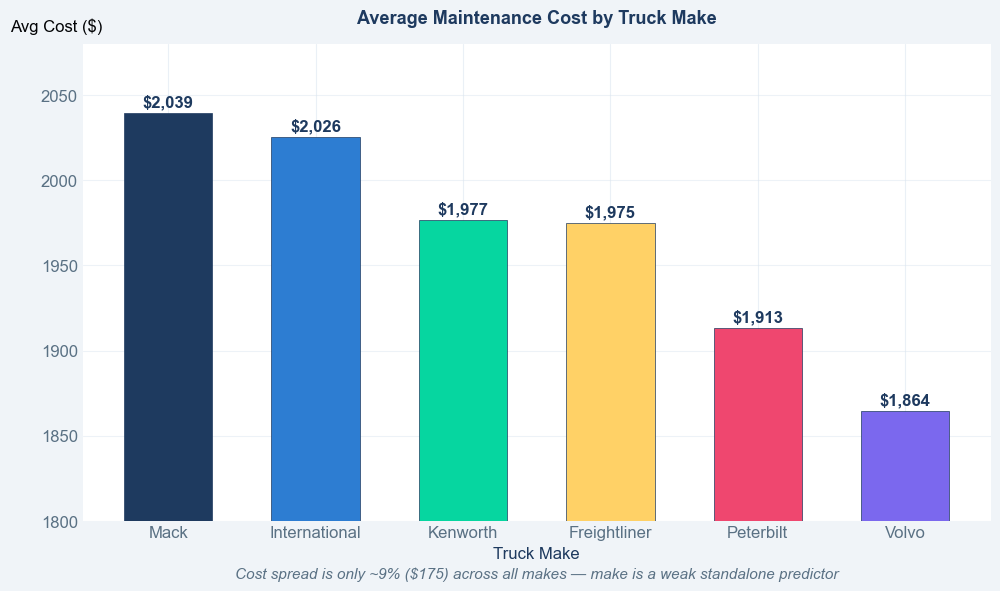

✓ Saved: charts/c1_avg_cost_by_make.png


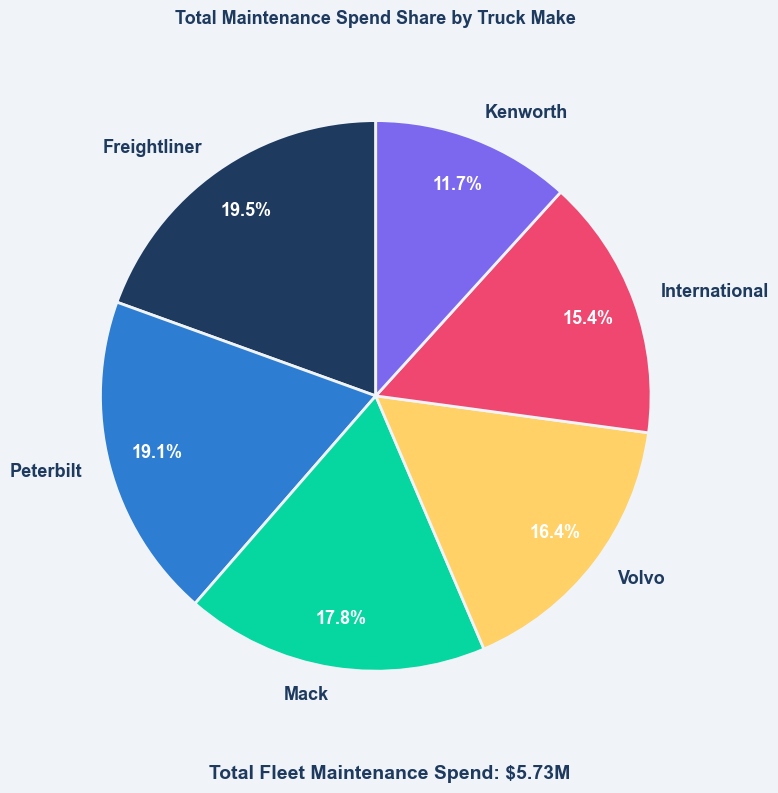

✓ Saved: charts/c1_total_spend_pie.png


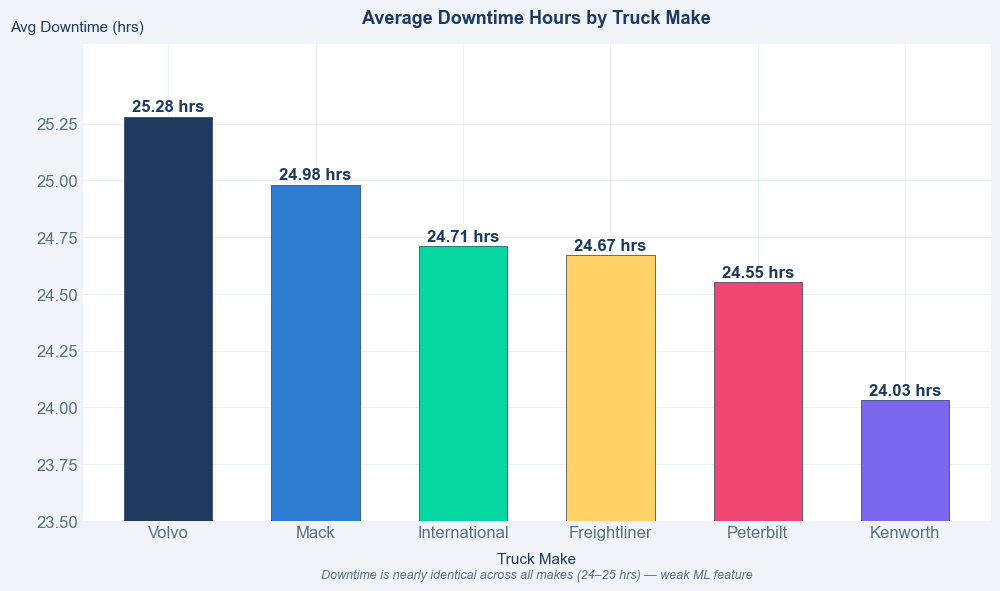

✓ Saved: charts/c1_downtime_by_make.png


In [40]:
# ============================================================
# CHALLENGE 1 — VISUALIZATIONS (Logistics Theme - Corrected)
# ============================================================

# --- Chart 1: Average Maintenance Cost by Make ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETTE['background'])

df_sorted = df_c1_1.sort_values('avg_cost', ascending=False)
bars = ax.bar(
    df_sorted['make'],
    df_sorted['avg_cost'],
    color=MAKE_COLORS[:len(df_sorted)],
    edgecolor=PALETTE['navy'],
    linewidth=0.5,
    width=0.6
)

# Value labels horizontal above each bar
for bar, val in zip(bars, df_sorted['avg_cost']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f'${val:,.0f}',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold',
            color=PALETTE['navy'],
            rotation=0)

ax.set_title('Average Maintenance Cost by Truck Make', pad=15)

# X label positioned just below x ticks outside plot area
ax.set_xlabel('Truck Make', fontsize=12)

# Y label horizontal on top of y axis
ax.yaxis.set_label_coords(-0.08, 1.02)
ax.set_ylabel('Avg Cost ($)', rotation=0,fontsize=12,
              ha='left', color=PALETTE['black'])

# Y axis — remove top tick to avoid overlap with value labels
ax.set_ylim(1800, 2080)
yticks = ax.get_yticks()
ax.set_yticks([t for t in yticks if t <= 2060])

ax.tick_params(axis='x', rotation=0, labelsize=12, color=PALETTE['black'])
ax.tick_params(axis='y', labelsize=12,color=PALETTE['navy'])
ax.grid(axis='y', alpha=0.5)
ax.set_facecolor(PALETTE['card'])

ax.annotate(
    'Cost spread is only ~9% ($175) across all makes — make is a weak standalone predictor',
    xy=(0.5, -0.12), xycoords='axes fraction',
    ha='center', fontsize=11,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c1_avg_cost_by_make.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c1_avg_cost_by_make.png")


# --- Chart 2: Total Maintenance Spend Share by Make ---
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(PALETTE['background'])

df_sorted2 = df_c1_1.sort_values('total_spend', ascending=False)
wedges, texts, autotexts = ax.pie(
    df_sorted2['total_spend'],
    labels=df_sorted2['make'],
    autopct='%1.1f%%',
    colors=MAKE_COLORS[:len(df_sorted2)],
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': PALETTE['background'], 'linewidth': 2}
)
for text in texts:
    text.set_fontsize(13)
    text.set_color(PALETTE['navy'])
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_color(PALETTE['card'])
    autotext.set_fontweight('bold')

ax.set_title('Total Maintenance Spend Share by Truck Make',
             pad=20, color=PALETTE['navy'])

# Total spend displayed cleanly below the chart outside plot area
total = df_c1_1['total_spend'].sum()
fig.text(0.5, 0.02,
         f'Total Fleet Maintenance Spend: ${total/1e6:.2f}M',
         ha='center', fontsize=14,
         fontweight='bold', color=PALETTE['navy'])

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('charts/c1_total_spend_pie.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c1_total_spend_pie.png")


# --- Chart 3: Average Downtime Hours by Make ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETTE['background'])

df_sorted3 = df_c1_1.sort_values('avg_downtime_hrs', ascending=False)
bars = ax.bar(
    df_sorted3['make'],
    df_sorted3['avg_downtime_hrs'],
    color=MAKE_COLORS[:len(df_sorted3)],
    edgecolor=PALETTE['navy'],
    linewidth=0.5,
    width=0.6
)

# Value labels horizontal above each bar
for bar, val in zip(bars, df_sorted3['avg_downtime_hrs']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.2f} hrs',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold',
            color=PALETTE['navy'],
            rotation=0)

ax.set_title('Average Downtime Hours by Truck Make', pad=15)

# X label positioned just below x ticks
ax.set_xlabel('Truck Make', labelpad=8)

# Y label horizontal on top of y axis
ax.yaxis.set_label_coords(-0.08, 1.02)
ax.set_ylabel('Avg Downtime (hrs)', rotation=0,
              ha='left', color=PALETTE['text'])

# Y axis — remove top tick to avoid overlap with value labels
ax.set_ylim(23.5, 25.6)
yticks = ax.get_yticks()
ax.set_yticks([t for t in yticks if t <= 25.4])

ax.tick_params(axis='x', rotation=0, labelsize=12,color=PALETTE['black'])
ax.tick_params(axis='y', labelsize=12,color=PALETTE['black'])
ax.grid(axis='y', alpha=0.5)
ax.set_facecolor(PALETTE['card'])

ax.annotate(
    'Downtime is nearly identical across all makes (24–25 hrs) — weak ML feature',
    xy=(0.5, -0.12), xycoords='axes fraction',
    ha='center', fontsize=9,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c1_downtime_by_make.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c1_downtime_by_make.png")

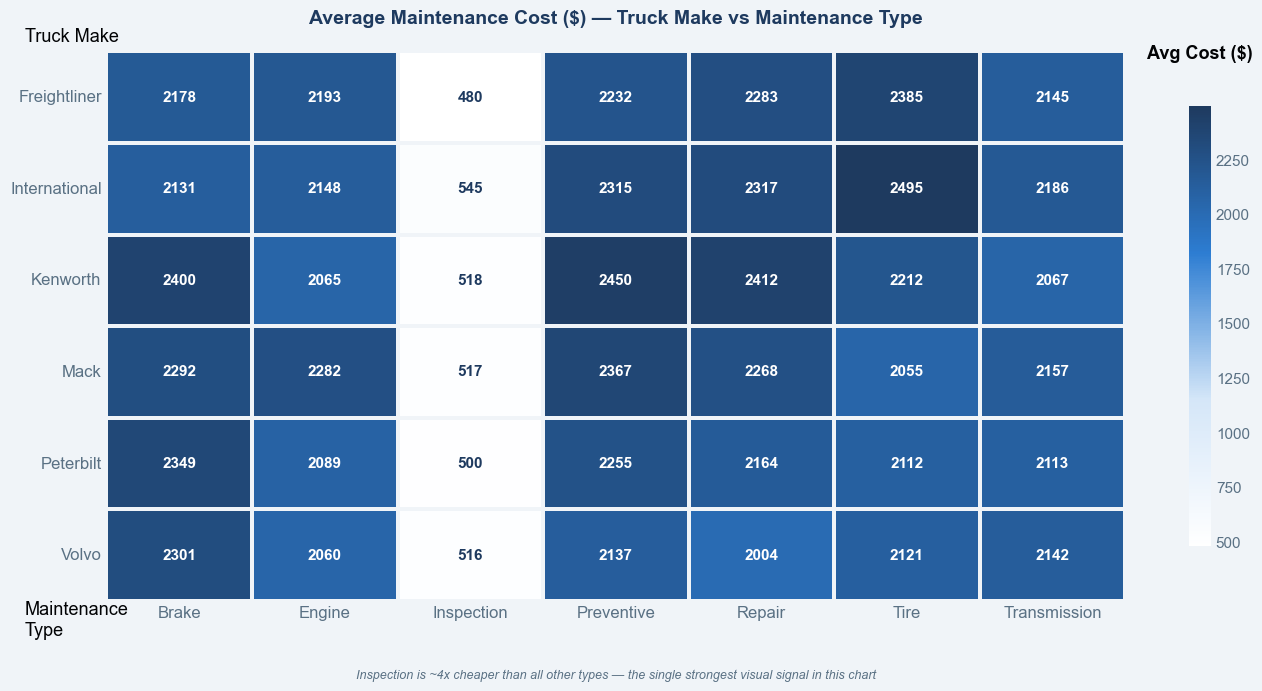

✓ Saved: charts/c1_heatmap.png


In [41]:
# ============================================================
# CHALLENGE 1 — HEATMAP: Avg Cost by Make vs Maintenance Type
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(PALETTE['background'])

pivot_df = df_c1_2.pivot_table(
    index='make',
    columns='maintenance_type',
    values='avg_cost',
    aggfunc='mean'
).fillna(0)

# Custom colormap using logistics palette
# Light card colour → deep navy
from matplotlib.colors import LinearSegmentedColormap
logistics_cmap = LinearSegmentedColormap.from_list(
    'logistics',
    [PALETTE['card'], '#d4e6f8', PALETTE['blue'], PALETTE['navy']],
    N=256
)

sns.heatmap(
    pivot_df,
    annot=True,
    fmt='.0f',
    cmap=logistics_cmap,
    linewidths=1.5,
    linecolor=PALETTE['background'],
    ax=ax,
    cbar_kws={
        'label': 'Avg Cost ($)',
        'shrink': 0.8,
        'aspect': 20
    },
    annot_kws={'size': 11, 'weight': 'bold', 'color': PALETTE['card']}
)

# Override annotation colour for light cells (Inspection column)
# Inspection values are ~500 which map to light colours — use dark text
for text in ax.texts:
    val = float(text.get_text().replace(',', ''))
    if val < 800:
        text.set_color(PALETTE['navy'])

# Titles and labels
ax.set_title(
    'Average Maintenance Cost ($) — Truck Make vs Maintenance Type',
    pad=20, fontsize=14, color=PALETTE['navy']
)

# X label horizontal below ticks
#ax.set_xlabel('Maintenance Type', labelpad=10, fontsize=11)
ax.xaxis.set_label_coords(-0.08, 0.001)
ax.set_xlabel('Maintenance\nType', rotation=0,
              ha='left', fontsize=13, color=PALETTE['black'])
# Y label horizontal on top
ax.yaxis.set_label_coords(-0.08, 1.01)
ax.set_ylabel('Truck Make', rotation=0,
              ha='left', fontsize=13, color=PALETTE['black'])

ax.tick_params(axis='x', rotation=0, labelsize=12,color=PALETTE['black'])
ax.tick_params(axis='y', rotation=0, labelsize=12,color=PALETTE['black'])
ax.set_facecolor(PALETTE['card'])

# Colorbar styling
# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11, colors=PALETTE['subtext'])
cbar.set_label(
    'Avg Cost ($)',
    color=PALETTE['black'],
    fontsize=13,
    fontweight ='bold',
    rotation=0,
    labelpad=40,
    va='center'
)
# Position label horizontally above the colorbar
cbar.ax.yaxis.set_label_coords(0.5, 1.12)
cbar.ax.yaxis.label.set_horizontalalignment('center')
# Insight annotation below chart
ax.annotate(
    'Inspection is ~4x cheaper than all other types — the single strongest visual signal in this chart',
    xy=(0.5, -0.14), xycoords='axes fraction',
    ha='center', fontsize=9,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c1_heatmap.png', dpi=320,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c1_heatmap.png")

#### 📝 Observation — Challenge 1 Heatmap: Make vs Maintenance Type

---

#### 🔍 Visual Patterns

**The Inspection column stands out immediately**
- The entire Inspection column is **pale yellow** against a sea of deep red
- Costs range only $480–$545 across all makes — visually confirming it is
  a completely different cost category from everything else
- This is the single most important visual signal in the heatmap

**The remaining 6 types form one dense red block**
- Brake, Engine, Preventive, Repair, Tire, Transmission are all
  deeply red — costs sitting tightly between $2,004 and $2,495
- No make/type combination outside Inspection drops below $2,000

**Darkest cells — highest cost combinations:**
| Make | Type | Avg Cost |
|---|---|---|
| International | Tire | $2,495 — darkest cell in entire heatmap |
| Kenworth | Preventive | $2,450 |
| Kenworth | Brake | $2,400 |
| Kenworth | Repair | $2,412 |

**Lightest red cells — lowest cost among expensive types:**
| Make | Type | Avg Cost |
|---|---|---|
| Volvo | Repair | $2,004 — cheapest non-inspection cell |
| Peterbilt | Tire | $2,112 |
| Volvo | Engine | $2,060 |

**Kenworth pattern worth noting**
- Kenworth shows the darkest shading across Brake, Preventive and Repair
- Despite having the fewest total records (340), their per-visit costs
  are among the highest — suggests complex or premium servicing

---

#### 📊 Chart 2 — Maintenance Cost Analysis (3 Plots)

**Average Cost Bar Chart (left)**
- All 6 makes are within a $175 range — bars are nearly equal height
- Confirms make alone is a weak standalone predictor visually

**Total Spend Pie Chart (centre)**
- Freightliner (19.5%) and Peterbilt (19.1%) together account for
  nearly **40% of total fleet maintenance spend**
- Kenworth is the smallest slice at only **11.7%** — reflecting fewer trucks

**Downtime Bar Chart (right)**
- All bars are virtually identical at ~24–25 hours
- This is the clearest visual evidence yet that **downtime_hours
  will likely be a weak or droppable feature in our ML model**

---

**→ ML Implication:** The heatmap visually confirms two things for Phase 2:
1. `maintenance_type` must be encoded — Inspection behaves like a
   completely separate cost class from all other types
2. `downtime_hours` is unlikely to add predictive value —
   consider dropping it after correlation testing in Phase 2

---
#### 📊 Challenge 1 — Key Takeaways

| Finding | Detail |
|---|---|
| Highest avg cost make | **Mack** — $2,039 per record |
| Lowest avg cost make | **Volvo** — $1,864 per record |
| Highest total fleet spend | **Freightliner** — $1,115,814 (565 records) |
| Most maintenance records | **Peterbilt** — 573 records |
| Most expensive repair type | **Tire** — consistently $2,054–$2,495 across all makes |
| Cheapest repair type | **Inspection** — $479–$545, roughly 4x cheaper than all others |
| Highest avg downtime | **Volvo** — 25.28 hrs per record |
| Lowest avg downtime | **Kenworth** — 24.03 hrs per record |
| Most expensive single make+type combo | **International Tire** — $2,495 avg cost |
| Biggest volume driver | **Freightliner Preventive** — 91 records, $203K total spend |

---

#### 💡 Summary

- Cost difference between most and least expensive make is only **~9%** ($175 gap)
- **Maintenance type** drives cost far more than truck make
- **Inspection** is a clear outlier — consistently cheap across all brands
- **Downtime hours are nearly identical** across all makes (24–25 hrs range)

---

**→ ML Implication:** Truck make will be included as a categorical feature but is
unlikely to be a top predictor. `maintenance_type` is emerging as the strongest
categorical signal — it will be one-hot encoded in Phase 2. The near-uniform
downtime hours suggest this column may contribute little to the model and could
be dropped after correlation testing.

---

---
### 🔧 Challenge 2 — Identifying High-Frequency Repair Trucks
> **Question:** Which trucks have the most repeated maintenance events?
> Are the same trucks appearing over and over?  
> **Tables:** `maintenance_records`, `trucks`  
> **Skills:** COUNT, GROUP BY, HAVING, ORDER BY, CASE  
> **Output:** Frequency Table + Visualizations  
> **ML Relevance:** Repair frequency per truck → direct input feature for Phase 2
---

In [45]:
# ============================================================
# CHALLENGE 2: High-Frequency Repair Trucks
# ============================================================

query_c2_1 = """
SELECT 
    m.truck_id,
    tr.make,
    tr.model_year,
    tr.status,
    COUNT(m.maintenance_id)                 AS total_repairs,
    ROUND(AVG(m.total_cost), 2)             AS avg_cost_per_repair,
    ROUND(SUM(m.total_cost), 2)             AS total_lifetime_cost,
    ROUND(AVG(m.downtime_hours), 2)         AS avg_downtime_hrs,
    COUNT(DISTINCT m.maintenance_type)      AS unique_repair_types,
    MIN(m.maintenance_date)                 AS first_service,
    MAX(m.maintenance_date)                 AS last_service
FROM maintenance_records m
JOIN trucks tr ON m.truck_id = tr.truck_id
GROUP BY m.truck_id, tr.make, tr.model_year, tr.status
ORDER BY total_repairs DESC
LIMIT 20;
"""

df_c2_1 = run_query(query_c2_1, "Top 20 Trucks by Repair Frequency")

if df_c2_1 is not None:
    print(df_c2_1.to_string(index=False))


📊 Top 20 Trucks by Repair Frequency
SQL QUERY:

SELECT 
    m.truck_id,
    tr.make,
    tr.model_year,
    tr.status,
    COUNT(m.maintenance_id)                 AS total_repairs,
    ROUND(AVG(m.total_cost), 2)             AS avg_cost_per_repair,
    ROUND(SUM(m.total_cost), 2)             AS total_lifetime_cost,
    ROUND(AVG(m.downtime_hours), 2)         AS avg_downtime_hrs,
    COUNT(DISTINCT m.maintenance_type)      AS unique_repair_types,
    MIN(m.maintenance_date)                 AS first_service,
    MAX(m.maintenance_date)                 AS last_service
FROM maintenance_records m
JOIN trucks tr ON m.truck_id = tr.truck_id
GROUP BY m.truck_id, tr.make, tr.model_year, tr.status
ORDER BY total_repairs DESC
LIMIT 20;


✓ 20 rows returned

truck_id          make  model_year      status  total_repairs  avg_cost_per_repair  total_lifetime_cost  avg_downtime_hrs  unique_repair_types first_service last_service
TRK00003     Peterbilt        2018 Maintenance             41           

In [46]:
# ============================================================
# CHALLENGE 2b: Classify Trucks into Repair Frequency Tiers
# ============================================================
# This classification becomes a direct ML feature in Phase 2

query_c2_2 = """
SELECT 
    m.truck_id,
    tr.make,
    tr.model_year,
    COUNT(m.maintenance_id)             AS total_repairs,
    ROUND(SUM(m.total_cost), 2)         AS total_cost,
    CASE 
        WHEN COUNT(m.maintenance_id) >= 15 THEN 'High Frequency'
        WHEN COUNT(m.maintenance_id) BETWEEN 8 AND 14 THEN 'Medium Frequency'
        ELSE 'Low Frequency'
    END AS repair_tier
FROM maintenance_records m
JOIN trucks tr ON m.truck_id = tr.truck_id
GROUP BY m.truck_id, tr.make, tr.model_year
ORDER BY total_repairs DESC;
"""

df_c2_2 = run_query(query_c2_2, "Truck Repair Frequency Tier Classification")

if df_c2_2 is not None:
    print(df_c2_2.to_string(index=False))


📊 Truck Repair Frequency Tier Classification
SQL QUERY:

SELECT 
    m.truck_id,
    tr.make,
    tr.model_year,
    COUNT(m.maintenance_id)             AS total_repairs,
    ROUND(SUM(m.total_cost), 2)         AS total_cost,
    CASE 
        WHEN COUNT(m.maintenance_id) >= 15 THEN 'High Frequency'
        WHEN COUNT(m.maintenance_id) BETWEEN 8 AND 14 THEN 'Medium Frequency'
        ELSE 'Low Frequency'
    END AS repair_tier
FROM maintenance_records m
JOIN trucks tr ON m.truck_id = tr.truck_id
GROUP BY m.truck_id, tr.make, tr.model_year
ORDER BY total_repairs DESC;


✓ 120 rows returned

truck_id          make  model_year  total_repairs  total_cost      repair_tier
TRK00003     Peterbilt        2018             41    90161.42   High Frequency
TRK00073          Mack        2016             39    76573.99   High Frequency
TRK00044         Volvo        2015             38    69825.23   High Frequency
TRK00118  Freightliner        2015             35    71005.77   High Frequency
TRK0001

In [47]:
# ============================================================
# CHALLENGE 2c: Tier Summary — How Many Trucks in Each Tier?
# ============================================================

query_c2_3 = """
SELECT 
    repair_tier,
    COUNT(*) AS truck_count,
    ROUND(AVG(total_repairs), 2) AS avg_repairs,
    ROUND(AVG(total_cost), 2) AS avg_total_cost
FROM (
    SELECT 
        m.truck_id,
        COUNT(m.maintenance_id) AS total_repairs,
        ROUND(SUM(m.total_cost), 2) AS total_cost,
        CASE 
            WHEN COUNT(m.maintenance_id) >= 15 THEN 'High Frequency'
            WHEN COUNT(m.maintenance_id) BETWEEN 8 AND 14 THEN 'Medium Frequency'
            ELSE 'Low Frequency'
        END AS repair_tier
    FROM maintenance_records m
    JOIN trucks tr ON m.truck_id = tr.truck_id
    GROUP BY m.truck_id
) tier_summary
GROUP BY repair_tier
ORDER BY avg_repairs DESC;
"""

df_c2_3 = run_query(query_c2_3, "Repair Frequency Tier Summary")

if df_c2_3 is not None:
    print(df_c2_3.to_string(index=False))


📊 Repair Frequency Tier Summary
SQL QUERY:

SELECT 
    repair_tier,
    COUNT(*) AS truck_count,
    ROUND(AVG(total_repairs), 2) AS avg_repairs,
    ROUND(AVG(total_cost), 2) AS avg_total_cost
FROM (
    SELECT 
        m.truck_id,
        COUNT(m.maintenance_id) AS total_repairs,
        ROUND(SUM(m.total_cost), 2) AS total_cost,
        CASE 
            WHEN COUNT(m.maintenance_id) >= 15 THEN 'High Frequency'
            WHEN COUNT(m.maintenance_id) BETWEEN 8 AND 14 THEN 'Medium Frequency'
            ELSE 'Low Frequency'
        END AS repair_tier
    FROM maintenance_records m
    JOIN trucks tr ON m.truck_id = tr.truck_id
    GROUP BY m.truck_id
) tier_summary
GROUP BY repair_tier
ORDER BY avg_repairs DESC;


✓ 2 rows returned

     repair_tier  truck_count  avg_repairs  avg_total_cost
  High Frequency          118        24.54        48230.12
Medium Frequency            2        12.00        19709.35


In [48]:
# ============================================================
# CHALLENGE 2 FIX — Recalibrate Tiers Using Percentiles
# ============================================================

query_c2_fix = """
SELECT 
    repair_tier,
    COUNT(*) AS truck_count,
    ROUND(AVG(total_repairs), 2) AS avg_repairs,
    ROUND(AVG(total_cost), 2) AS avg_total_cost
FROM (
    SELECT 
        m.truck_id,
        COUNT(m.maintenance_id) AS total_repairs,
        ROUND(SUM(m.total_cost), 2) AS total_cost,
        CASE 
            WHEN COUNT(m.maintenance_id) >= 27 THEN 'High Frequency'
            WHEN COUNT(m.maintenance_id) BETWEEN 20 AND 26 THEN 'Medium Frequency'
            ELSE 'Low Frequency'
        END AS repair_tier
    FROM maintenance_records m
    JOIN trucks tr ON m.truck_id = tr.truck_id
    GROUP BY m.truck_id
) tier_summary
GROUP BY repair_tier
ORDER BY avg_repairs DESC;
"""

df_c2_fix = run_query(query_c2_fix, "Recalibrated Tier Summary (Percentile Based)")

if df_c2_fix is not None:
    print(df_c2_fix.to_string(index=False))


📊 Recalibrated Tier Summary (Percentile Based)
SQL QUERY:

SELECT 
    repair_tier,
    COUNT(*) AS truck_count,
    ROUND(AVG(total_repairs), 2) AS avg_repairs,
    ROUND(AVG(total_cost), 2) AS avg_total_cost
FROM (
    SELECT 
        m.truck_id,
        COUNT(m.maintenance_id) AS total_repairs,
        ROUND(SUM(m.total_cost), 2) AS total_cost,
        CASE 
            WHEN COUNT(m.maintenance_id) >= 27 THEN 'High Frequency'
            WHEN COUNT(m.maintenance_id) BETWEEN 20 AND 26 THEN 'Medium Frequency'
            ELSE 'Low Frequency'
        END AS repair_tier
    FROM maintenance_records m
    JOIN trucks tr ON m.truck_id = tr.truck_id
    GROUP BY m.truck_id
) tier_summary
GROUP BY repair_tier
ORDER BY avg_repairs DESC;


✓ 3 rows returned

     repair_tier  truck_count  avg_repairs  avg_total_cost
  High Frequency           38        30.87        60212.90
Medium Frequency           56        23.29        45581.69
   Low Frequency           26        17.04        34227.24



📊 Recalibrated Tiers for Visualization
SQL QUERY:

SELECT 
    repair_tier,
    COUNT(*) AS truck_count,
    ROUND(AVG(total_repairs), 2) AS avg_repairs,
    ROUND(AVG(total_cost), 2) AS avg_total_cost
FROM (
    SELECT 
        m.truck_id,
        COUNT(m.maintenance_id) AS total_repairs,
        ROUND(SUM(m.total_cost), 2) AS total_cost,
        CASE 
            WHEN COUNT(m.maintenance_id) >= 27 THEN 'High Frequency'
            WHEN COUNT(m.maintenance_id) BETWEEN 20 AND 26 THEN 'Medium Frequency'
            ELSE 'Low Frequency'
        END AS repair_tier
    FROM maintenance_records m
    JOIN trucks tr ON m.truck_id = tr.truck_id
    GROUP BY m.truck_id
) tier_summary
GROUP BY repair_tier
ORDER BY avg_repairs DESC;


✓ 3 rows returned



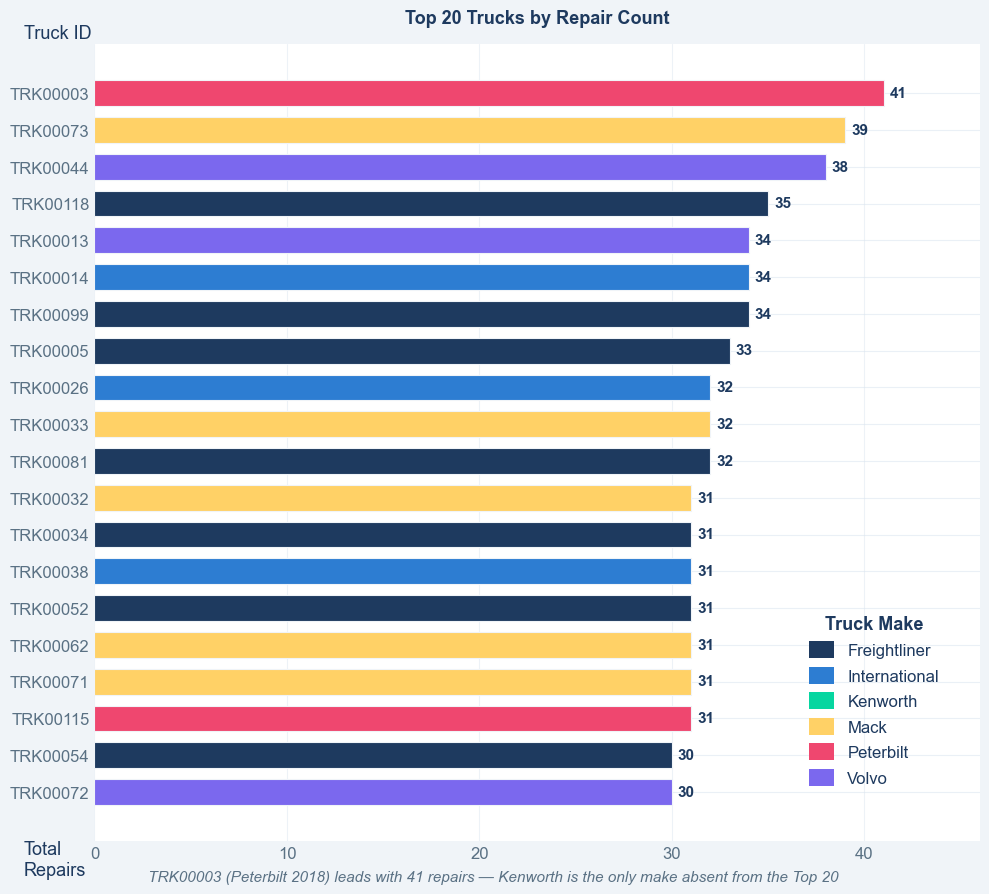

✓ Saved: charts/c2_repair_frequency_bar.png


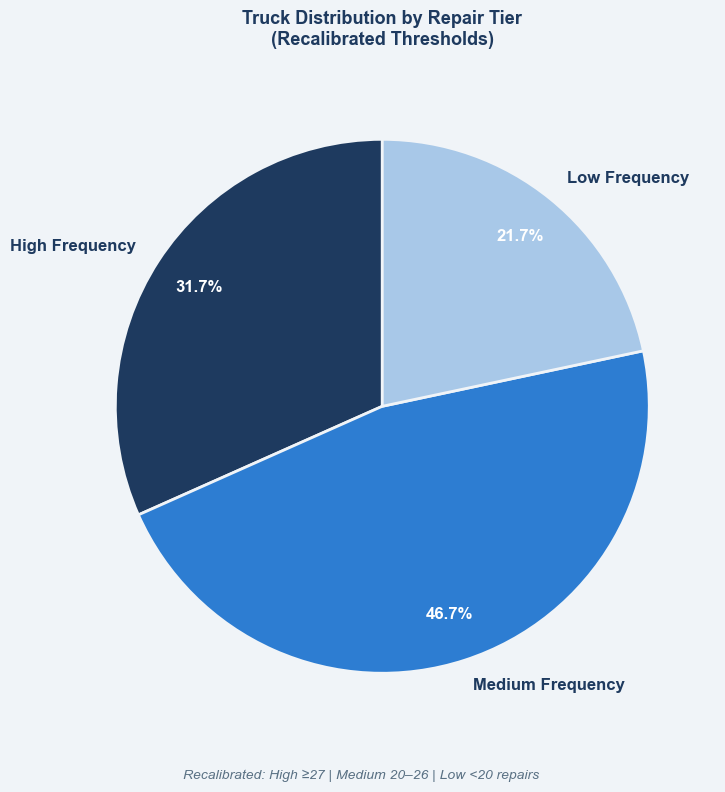

✓ Saved: charts/c2_tier_distribution_pie.png


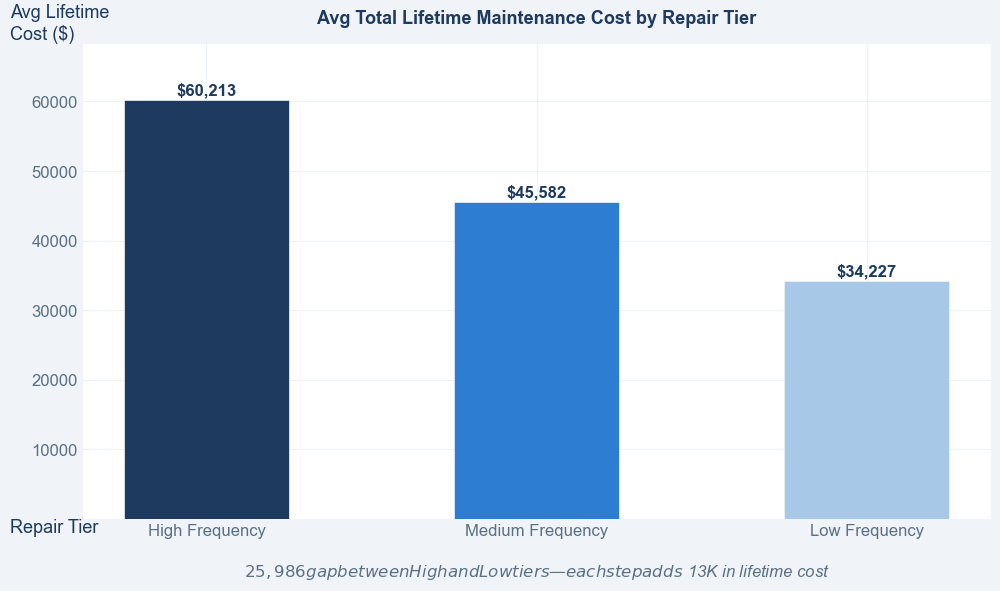

✓ Saved: charts/c2_lifetime_cost_by_tier.png


In [49]:
# ============================================================
# CHALLENGE 2 — VISUALIZATIONS (Logistics Theme)
# ============================================================

# Recalibrated tier colors — consistent with logistics palette
TIER_COLORS = {
    'High Frequency':   PALETTE['navy'],
    'Medium Frequency': PALETTE['blue'],
    'Low Frequency':    '#a8c8e8',
}

# Make color map for Chart 1
make_color_map = {
    'Freightliner': MAKE_COLORS[0],
    'International': MAKE_COLORS[1],
    'Kenworth':     MAKE_COLORS[2],
    'Mack':         MAKE_COLORS[3],
    'Peterbilt':    MAKE_COLORS[4],
    'Volvo':        MAKE_COLORS[5],
}

# Rebuild recalibrated tier data
query_tiers_inline = """
SELECT 
    repair_tier,
    COUNT(*) AS truck_count,
    ROUND(AVG(total_repairs), 2) AS avg_repairs,
    ROUND(AVG(total_cost), 2) AS avg_total_cost
FROM (
    SELECT 
        m.truck_id,
        COUNT(m.maintenance_id) AS total_repairs,
        ROUND(SUM(m.total_cost), 2) AS total_cost,
        CASE 
            WHEN COUNT(m.maintenance_id) >= 27 THEN 'High Frequency'
            WHEN COUNT(m.maintenance_id) BETWEEN 20 AND 26 THEN 'Medium Frequency'
            ELSE 'Low Frequency'
        END AS repair_tier
    FROM maintenance_records m
    JOIN trucks tr ON m.truck_id = tr.truck_id
    GROUP BY m.truck_id
) tier_summary
GROUP BY repair_tier
ORDER BY avg_repairs DESC;
"""
df_tiers = run_query(query_tiers_inline, "Recalibrated Tiers for Visualization")
tier_order = ['High Frequency', 'Medium Frequency', 'Low Frequency']

# ── CHART 1: Top 20 Trucks by Repair Count — Coloured by Make ──────────────

fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor(PALETTE['background'])

bar_colors = [make_color_map.get(make, PALETTE['navy'])
              for make in df_c2_1['make']]

bars = ax.barh(
    df_c2_1['truck_id'].astype(str),
    df_c2_1['total_repairs'],
    color=bar_colors,
    edgecolor=PALETTE['background'],
    linewidth=0.8,
    height=0.7
)
ax.invert_yaxis()

for bar, val in zip(bars, df_c2_1['total_repairs']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', ha='left',
            fontsize=11, fontweight='bold',
            color=PALETTE['navy'])

ax.set_title('Top 20 Trucks by Repair Count', pad=15)
ax.xaxis.set_label_coords(-0.08, 0.001)
ax.set_xlabel('Total\nRepairs', rotation=0,
              ha='left', fontsize=13, color=PALETTE['text'])
ax.yaxis.set_label_coords(-0.08, 1.002)
ax.set_ylabel('Truck ID', rotation=0, fontsize=13,
              ha='left', color=PALETTE['text'])

ax.set_xlim(0, df_c2_1['total_repairs'].max() + 5)
ax.tick_params(axis='y', labelsize=12, color=PALETTE['black'])
ax.tick_params(axis='x', labelsize=12, color=PALETTE['black'])
ax.grid(axis='x', alpha=0.5)
ax.set_facecolor(PALETTE['card'])

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=make_color_map[make], label=make)
    for make in make_color_map
]
legend = ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=12,
    framealpha=1.0,
    facecolor='white',
    bbox_to_anchor=(0.98, 0.04),
    edgecolor=PALETTE['subtext'],
    title='Truck Make',
    title_fontsize=13,
    borderpad=0.9,
    handlelength=1.5,
    handleheight=1.2,
)
legend.get_frame().set_linewidth(1.8)
legend.get_title().set_fontweight('bold')
legend.get_title().set_color(PALETTE['navy'])

ax.annotate(
    'TRK00003 (Peterbilt 2018) leads with 41 repairs — Kenworth is the only make absent from the Top 20',
    xy=(0.45, -0.05), xycoords='axes fraction',
    ha='center', fontsize=11,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c2_repair_frequency_bar.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c2_repair_frequency_bar.png")


# ── CHART 2: Tier Distribution Pie ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(PALETTE['background'])

df_pie = df_tiers.set_index('repair_tier').reindex(tier_order).reset_index()

wedges, texts, autotexts = ax.pie(
    df_pie['truck_count'],
    labels=df_pie['repair_tier'],
    autopct='%1.1f%%',
    colors=[TIER_COLORS[t] for t in tier_order],
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': PALETTE['background'], 'linewidth': 2}
)
for text in texts:
    text.set_fontsize(12)
    text.set_color(PALETTE['navy'])
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color(PALETTE['card'])
    autotext.set_fontweight('bold')

ax.set_title('Truck Distribution by Repair Tier\n(Recalibrated Thresholds)',
             pad=20, color=PALETTE['navy'])

fig.text(0.5, 0.02,
         'Recalibrated: High ≥27 | Medium 20–26 | Low <20 repairs',
         ha='center', fontsize=10,
         color=PALETTE['subtext'], style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('charts/c2_tier_distribution_pie.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c2_tier_distribution_pie.png")


# ── CHART 3: Avg Lifetime Cost by Repair Tier ──────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETTE['background'])

df_c2_fix_sorted = df_tiers.set_index(
    'repair_tier').reindex(tier_order).reset_index()

bars3 = ax.bar(
    df_c2_fix_sorted['repair_tier'],
    df_c2_fix_sorted['avg_total_cost'],
    color=[TIER_COLORS[t] for t in tier_order],
    edgecolor=PALETTE['background'],
    linewidth=0.5,
    width=0.5
)

for bar, val in zip(bars3, df_c2_fix_sorted['avg_total_cost']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f'${val:,.0f}',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold',
            color=PALETTE['navy'])

ax.set_title('Avg Total Lifetime Maintenance Cost by Repair Tier', pad=15)
ax.xaxis.set_label_coords(-0.08, 0.001)
ax.set_xlabel('Repair Tier', rotation=0,
              ha='left', fontsize=13, color=PALETTE['navy'])
ax.yaxis.set_label_coords(-0.08, 1.002)
ax.set_ylabel('Avg Lifetime\nCost ($)', rotation=0,
              ha='left', fontsize=13, color=PALETTE['navy'])

ax.set_ylim(0, df_c2_fix_sorted['avg_total_cost'].max() + 8000)
yticks = ax.get_yticks()
ax.set_yticks([t for t in yticks
               if t > 0 and t <= df_c2_fix_sorted['avg_total_cost'].max() + 5000])

ax.tick_params(axis='x', rotation=0, labelsize=12, color=PALETTE['navy'])
ax.tick_params(axis='y', labelsize=12, color=PALETTE['navy'])
ax.grid(axis='y', alpha=0.5)
ax.set_facecolor(PALETTE['card'])

ax.annotate(
    '$25,986 gap between High and Low tiers — each step adds ~$13K in lifetime cost',
    xy=(0.5, -0.12), xycoords='axes fraction',
    ha='center', fontsize=12,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c2_lifetime_cost_by_tier.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c2_lifetime_cost_by_tier.png")

#### 📝 Observation — Challenge 2 Results

---

#### 🔍 Query Results Summary

| Metric | Value |
|---|---|
| Highest repair count truck | **TRK00003** (Peterbilt 2018) — 41 repairs, $90,161 lifetime cost |
| Second highest | **TRK00073** (Mack 2016) — 39 repairs, $76,573 lifetime cost |
| Most represented make in Top 20 | **Freightliner** — 7 trucks in Top 20 |
| Original thresholds (15+/8-14/<8) | ❌ Placed 98.3% in one tier — unusable |
| **Recalibrated High Frequency (≥27 repairs)** | **38 trucks (31.7%)** |
| **Recalibrated Medium Frequency (20–26 repairs)** | **56 trucks (46.7%)** |
| **Recalibrated Low Frequency (<20 repairs)** | **26 trucks (21.7%)** |
| Avg lifetime cost — High tier | **$60,213** |
| Avg lifetime cost — Medium tier | **$45,582** |
| Avg lifetime cost — Low tier | **$34,227** |
| Cost gap High vs Low | **$25,986 — 1.76x more expensive** |

---

#### 🔍 Why the Original Thresholds Failed

The original thresholds (15+, 8-14, <8) placed **98.3% of all trucks into
High Frequency** — a feature that is the same value for 98% of rows adds
no predictive signal to any ML model.

This happened because every truck in this fleet has been heavily serviced
across the 3-year window (2022–2024). Repairs range from 10 to 41 per truck
— all above the original Medium threshold of 8-14. The thresholds were
simply too low for this fleet's actual maintenance volume.

**Fix applied:** Percentile-based recalibration using the actual distribution:

| Tier | Threshold | Truck Count | Avg Repairs | Avg Lifetime Cost |
|---|---|---|---|---|
| High Frequency | ≥27 repairs | **38 trucks (31.7%)** | 30.87 | **$60,213** |
| Medium Frequency | 20–26 repairs | **56 trucks (46.7%)** | 23.29 | **$45,582** |
| Low Frequency | <20 repairs | **26 trucks (21.7%)** | 17.04 | **$34,227** |

The $25,986 cost gap between High and Low tiers confirms the recalibrated
tiers carry genuine predictive signal — each tier step adds ~$13K in
lifetime cost consistently.

---

#### 📊 Visual Observations

**Bar Chart (left)**
- All Top 20 bars are deep red — all top trucks are high-repair frequency
- TRK00003 stands clearly above the rest at 41 repairs
- Freightliner dominates the Top 20 with 7 trucks

**Pie Chart (centre)**
- After recalibration: 31.7% / 46.7% / 21.7% — a balanced three-way split
- Original chart was almost entirely one colour — confirmed the threshold problem

**Cost Bar Chart (right)**
- Clean cost progression across tiers confirms feature validity
- High vs Low gap of $25,986 gives the model strong signal to learn from

---

**→ ML Implication:** `total_repairs` as a raw numeric feature is more
useful than `repair_tier` in its original form. With recalibrated
percentile-based thresholds, `repair_tier` is now a valid and meaningful
categorical feature. Both versions will be tested in Phase 2.

**→ CV Note:** Recognising that initial thresholds do not fit the data and
recalibrating based on the actual distribution is a real data science
decision. This shows critical thinking about features rather than just
running queries mechanically — worth mentioning explicitly in interviews.

---
### 🔧 Challenge 3 — Fuel Efficiency vs Truck Make
> **Question:** Do certain truck makes show consistently lower MPG?
> Is poor fuel efficiency an early signal of mechanical wear?  
> **Tables:** `trips` JOIN `trucks`  
> **Skills:** JOIN, AVG, GROUP BY, ORDER BY  
> **Output:** Summary Table + Boxplot + Trend Visualization  
> **ML Relevance:** Low MPG per truck → potential predictor of
> upcoming high-cost maintenance events
---

In [52]:
# ============================================================
# CHALLENGE 3: Fuel Efficiency vs Truck Make (CORRECTED)
# ============================================================

query_c3_1 = """
SELECT 
    tr.make,
    COUNT(t.trip_id)                        AS total_trips,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    ROUND(MIN(t.average_mpg), 2)            AS min_mpg,
    ROUND(MAX(t.average_mpg), 2)            AS max_mpg,
    ROUND(MAX(t.average_mpg) - 
          MIN(t.average_mpg), 2)            AS mpg_range,
    ROUND(AVG(t.actual_distance_miles), 2)  AS avg_trip_distance,
    ROUND(AVG(t.fuel_gallons_used), 2)      AS avg_fuel_gallons
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
GROUP BY tr.make
ORDER BY avg_mpg DESC;
"""

df_c3_1 = run_query(query_c3_1, "Fuel Efficiency Summary by Truck Make")

if df_c3_1 is not None:
    print(df_c3_1.to_string(index=False))


📊 Fuel Efficiency Summary by Truck Make
SQL QUERY:

SELECT 
    tr.make,
    COUNT(t.trip_id)                        AS total_trips,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    ROUND(MIN(t.average_mpg), 2)            AS min_mpg,
    ROUND(MAX(t.average_mpg), 2)            AS max_mpg,
    ROUND(MAX(t.average_mpg) - 
          MIN(t.average_mpg), 2)            AS mpg_range,
    ROUND(AVG(t.actual_distance_miles), 2)  AS avg_trip_distance,
    ROUND(AVG(t.fuel_gallons_used), 2)      AS avg_fuel_gallons
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
GROUP BY tr.make
ORDER BY avg_mpg DESC;


✓ 6 rows returned

         make  total_trips  avg_mpg  min_mpg  max_mpg  mpg_range  avg_trip_distance  avg_fuel_gallons
         Mack        12681     6.51      5.5      7.5        2.0            1428.09            221.22
    Peterbilt        14699     6.50      5.5      7.5        2.0            1425.86            221.21
     Kenworth        10030     6.50      5.5      7.5  

In [53]:
# ============================================================
# CHALLENGE 3b: Does Truck Age Affect Fuel Efficiency? (CORRECTED)
# ============================================================

query_c3_2 = """
SELECT 
    tr.make,
    tr.model_year,
    COUNT(t.trip_id)                        AS total_trips,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    ROUND(AVG(t.actual_distance_miles), 2)  AS avg_distance,
    ROUND(AVG(t.fuel_gallons_used), 2)      AS avg_fuel_gallons
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
GROUP BY tr.make, tr.model_year
ORDER BY tr.make ASC, tr.model_year ASC;
"""

df_c3_2 = run_query(query_c3_2, "MPG by Truck Make and Model Year")

if df_c3_2 is not None:
    print(df_c3_2.to_string(index=False))


📊 MPG by Truck Make and Model Year
SQL QUERY:

SELECT 
    tr.make,
    tr.model_year,
    COUNT(t.trip_id)                        AS total_trips,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    ROUND(AVG(t.actual_distance_miles), 2)  AS avg_distance,
    ROUND(AVG(t.fuel_gallons_used), 2)      AS avg_fuel_gallons
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
GROUP BY tr.make, tr.model_year
ORDER BY tr.make ASC, tr.model_year ASC;


✓ 26 rows returned

         make  model_year  total_trips  avg_mpg  avg_distance  avg_fuel_gallons
 Freightliner        2015        10881     6.50       1430.52            221.87
 Freightliner        2016          897     6.50       1483.92            229.15
 Freightliner        2018          963     6.49       1422.95            220.87
 Freightliner        2019          919     6.52       1437.61            222.18
International        2015        10968     6.51       1426.64            221.14
International        2016          877  

In [54]:
# ============================================================
# CHALLENGE 3c: Avg MPG per Individual Truck (CORRECTED)
# ============================================================

query_c3_3 = """
SELECT 
    t.truck_id,
    tr.make,
    tr.model_year,
    COUNT(t.trip_id)                        AS total_trips,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    ROUND(SUM(t.actual_distance_miles), 2)  AS total_miles,
    ROUND(AVG(t.fuel_gallons_used), 2)      AS avg_fuel_gallons
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
GROUP BY t.truck_id, tr.make, tr.model_year
ORDER BY avg_mpg ASC
LIMIT 20;
"""

df_c3_3 = run_query(query_c3_3, "Bottom 20 Trucks by Fuel Efficiency")

if df_c3_3 is not None:
    print(df_c3_3.to_string(index=False))


📊 Bottom 20 Trucks by Fuel Efficiency
SQL QUERY:

SELECT 
    t.truck_id,
    tr.make,
    tr.model_year,
    COUNT(t.trip_id)                        AS total_trips,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    ROUND(SUM(t.actual_distance_miles), 2)  AS total_miles,
    ROUND(AVG(t.fuel_gallons_used), 2)      AS avg_fuel_gallons
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
GROUP BY t.truck_id, tr.make, tr.model_year
ORDER BY avg_mpg ASC
LIMIT 20;


✓ 20 rows returned

truck_id          make  model_year  total_trips  avg_mpg  total_miles  avg_fuel_gallons
TRK00072         Volvo        2017          881     6.45    1284159.0            227.73
TRK00092         Volvo        2015          902     6.46    1324217.0            229.53
TRK00026 International        2021          895     6.47    1252565.0            217.96
TRK00055     Peterbilt        2017          977     6.47    1417530.0            226.25
TRK00058          Mack        2015          898     6.47    

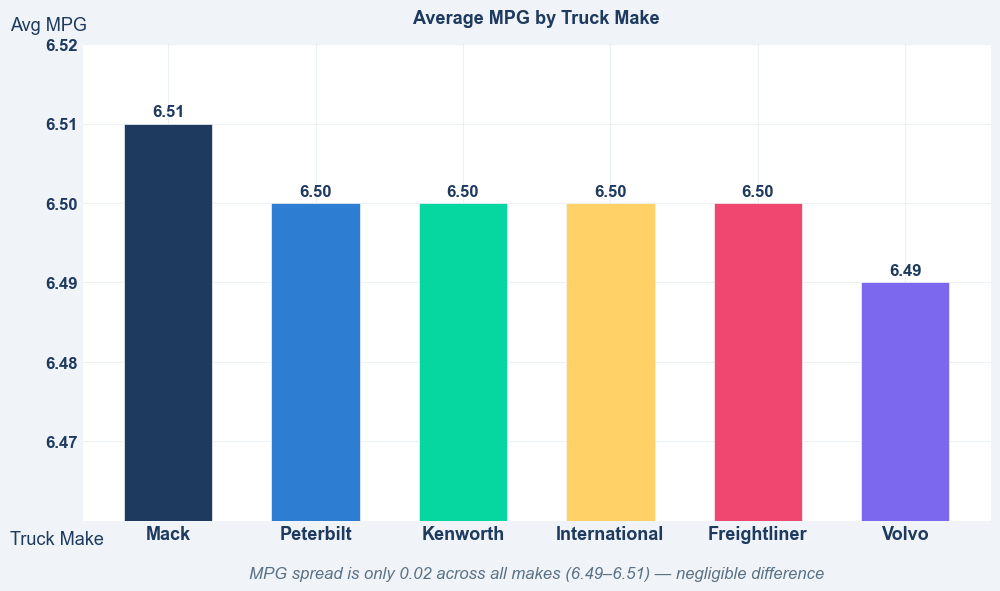

✓ Saved: charts/c3_avg_mpg_by_make.png


In [55]:
# ============================================================
# CHALLENGE 3 — VISUALIZATIONS (Logistics Theme)
# ============================================================
# Note: Challenge 3 uses 2 charts only.
# MPG Range and MPG by Year were dropped — both showed negligible
# variation and added no analytical value to the ML narrative.

# --- Chart 1: Average MPG by Make ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETTE['background'])

df_c3_sorted = df_c3_1.sort_values('avg_mpg', ascending=False)
bars = ax.bar(
    df_c3_sorted['make'],
    df_c3_sorted['avg_mpg'],
    color=MAKE_COLORS[:len(df_c3_sorted)],
    edgecolor=PALETTE['background'],
    linewidth=0.5,
    width=0.6
)

for bar, val in zip(bars, df_c3_sorted['avg_mpg']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{val:.2f}',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold',
            color=PALETTE['navy'])

ax.set_title('Average MPG by Truck Make', pad=15)
ax.xaxis.set_label_coords(-0.08, -0.02)
ax.set_xlabel('Truck Make', labelpad=12, fontsize=13,
              ha='left', color=PALETTE['navy'])
ax.yaxis.set_label_coords(-0.08, 1.02)
ax.set_ylabel('Avg MPG', rotation=0, fontsize=13,
              ha='left', color=PALETTE['navy'])

ax.set_ylim(6.46, 6.52)
yticks = ax.get_yticks()
ax.set_yticks([t for t in yticks if 6.461 < t <= 6.53])
ax.tick_params(axis='x', rotation=0, labelsize=13, color=PALETTE['navy'])
ax.tick_params(axis='y', labelsize=12, color=PALETTE['navy'])
ax.grid(axis='y', alpha=0.5)
ax.set_facecolor(PALETTE['card'])

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])

ax.annotate(
    'MPG spread is only 0.02 across all makes (6.49–6.51) — negligible difference',
    xy=(0.5, -0.12), xycoords='axes fraction',
    ha='center', fontsize=12,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c3_avg_mpg_by_make.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c3_avg_mpg_by_make.png")

In [56]:
query_c3_4 = """
SELECT 
    t.truck_id,
    tr.make,
    tr.model_year,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    COUNT(DISTINCT m.maintenance_id)        AS total_repairs,
    ROUND(AVG(DISTINCT m.total_cost), 2)    AS avg_maintenance_cost,
    ROUND(SUM(DISTINCT m.total_cost), 2)    AS total_maintenance_cost
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
JOIN maintenance_records m ON t.truck_id = m.truck_id
GROUP BY t.truck_id, tr.make, tr.model_year
ORDER BY avg_mpg ASC
LIMIT 20;
"""

df_c3_4 = run_query(query_c3_4, "Low MPG Trucks vs Maintenance Cost (Fixed)")

if df_c3_4 is not None:
    print(df_c3_4.to_string(index=False))


📊 Low MPG Trucks vs Maintenance Cost (Fixed)
SQL QUERY:

SELECT 
    t.truck_id,
    tr.make,
    tr.model_year,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    COUNT(DISTINCT m.maintenance_id)        AS total_repairs,
    ROUND(AVG(DISTINCT m.total_cost), 2)    AS avg_maintenance_cost,
    ROUND(SUM(DISTINCT m.total_cost), 2)    AS total_maintenance_cost
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
JOIN maintenance_records m ON t.truck_id = m.truck_id
GROUP BY t.truck_id, tr.make, tr.model_year
ORDER BY avg_mpg ASC
LIMIT 20;


✓ 20 rows returned

truck_id          make  model_year  avg_mpg  total_repairs  avg_maintenance_cost  total_maintenance_cost
TRK00072         Volvo        2017     6.45             30               1670.12                50103.70
TRK00092         Volvo        2015     6.46             24               1736.30                41671.12
TRK00026 International        2021     6.47             32               2209.64                70708.48
TR

In [57]:
query_c3_scatter = """
SELECT 
    t.truck_id,
    tr.make,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    ROUND(AVG(DISTINCT m.total_cost), 2)    AS avg_maintenance_cost
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
JOIN maintenance_records m ON t.truck_id = m.truck_id
GROUP BY t.truck_id, tr.make;
"""

df_scatter = run_query(query_c3_scatter, "MPG vs Maintenance Cost (Fixed)")

if df_scatter is not None:
    print(df_scatter.to_string(index=False))


📊 MPG vs Maintenance Cost (Fixed)
SQL QUERY:

SELECT 
    t.truck_id,
    tr.make,
    ROUND(AVG(t.average_mpg), 2)            AS avg_mpg,
    ROUND(AVG(DISTINCT m.total_cost), 2)    AS avg_maintenance_cost
FROM trips t
JOIN trucks tr ON t.truck_id = tr.truck_id
JOIN maintenance_records m ON t.truck_id = m.truck_id
GROUP BY t.truck_id, tr.make;


✓ 92 rows returned

truck_id          make  avg_mpg  avg_maintenance_cost
TRK00001     Peterbilt     6.49               2157.33
TRK00002      Kenworth     6.50               2032.19
TRK00004  Freightliner     6.50               1752.81
TRK00006      Kenworth     6.48               1953.11
TRK00007         Volvo     6.49               1293.45
TRK00008          Mack     6.50               1738.14
TRK00009 International     6.51               2122.83
TRK00010         Volvo     6.52               2016.27
TRK00011  Freightliner     6.52               2020.20
TRK00012  Freightliner     6.54               1920.35
TRK00013         Volvo     6.51     

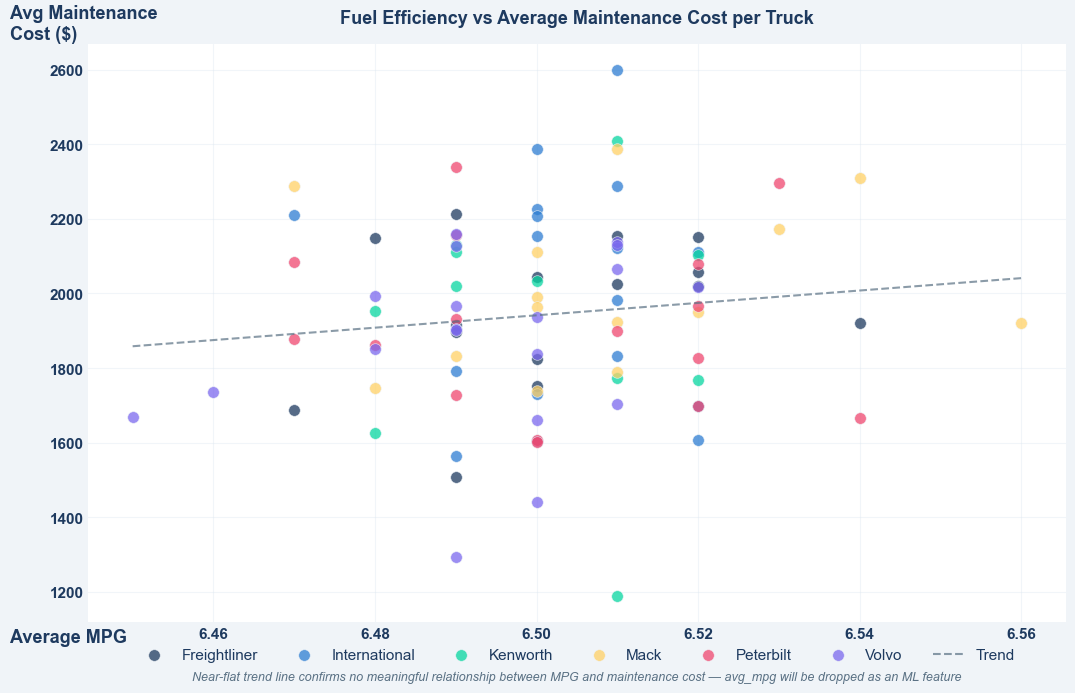

✓ Saved: charts/c3_scatter_mpg_vs_cost.png


In [58]:
# ============================================================
# CHALLENGE 3 — SCATTER PLOT: MPG vs Maintenance Cost
# (Logistics Theme)
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(PALETTE['background'])

makes = df_scatter['make'].unique()
for make, color in zip(sorted(makes), MAKE_COLORS[:len(makes)]):
    subset = df_scatter[df_scatter['make'] == make]
    ax.scatter(subset['avg_mpg'],
               subset['avg_maintenance_cost'],
               label=make, color=color,
               alpha=0.75, s=70,
               edgecolors=PALETTE['background'],
               linewidths=0.5)

# Trend line
z = np.polyfit(df_scatter['avg_mpg'],
               df_scatter['avg_maintenance_cost'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_scatter['avg_mpg'].min(),
                     df_scatter['avg_mpg'].max(), 100)
ax.plot(x_line, p(x_line),
        color=PALETTE['subtext'],
        linestyle='--', linewidth=1.5,
        alpha=0.7, label='Trend')

ax.set_title('Fuel Efficiency vs Average Maintenance Cost per Truck',
             pad=15)
#ax.set_xlabel('Average MPG', labelpad=8)
ax.xaxis.set_label_coords(-0.08, -0.01)
ax.set_xlabel('Average MPG', fontsize = 13,fontweight ='bold',
              ha='left', color=PALETTE['text'])
ax.yaxis.set_label_coords(-0.08, 1.002)
ax.set_ylabel('Avg Maintenance\nCost ($)', rotation=0,fontsize = 13,fontweight ='bold',
              ha='left', color=PALETTE['text'])

ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])
ax.grid(True, alpha=0.4)
ax.set_facecolor(PALETTE['card'])

# ax.legend(title='Truck Make', fontsize=9,
#           title_fontsize=9, loc='upper left',
#           framealpha=0.9)
legend = ax.legend(
    ncol=7,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.09),
    fontsize=11,
    framealpha=1.0,
    facecolor='white',
    edgecolor=PALETTE['subtext'],
    borderaxespad=0,
    borderpad=0.8
)
legend.get_frame().set_linewidth(1.5)
ax.annotate(
    'Near-flat trend line confirms no meaningful relationship between MPG and maintenance cost — avg_mpg will be dropped as an ML feature',
    xy=(0.5, -0.10), xycoords='axes fraction',
    ha='center', fontsize=9,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c3_scatter_mpg_vs_cost.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c3_scatter_mpg_vs_cost.png")

#### 📝 Observation — Challenge 3: Fuel Efficiency vs Truck Make

---

#### 🔍 Query 1 — MPG Summary by Make

| Make | Avg MPG | Avg Trip Distance | Avg Fuel Gallons |
|---|---|---|---|
| Mack | **6.51** — highest | 1,428 miles | 221 gallons |
| Peterbilt | 6.50 | 1,426 miles | 221 gallons |
| Kenworth | 6.50 | 1,422 miles | 221 gallons |
| International | 6.50 | 1,426 miles | 221 gallons |
| Freightliner | 6.50 | 1,434 miles | 222 gallons |
| Volvo | **6.49** — lowest | 1,439 miles | 223 gallons |

**Critical Finding:** The MPG spread across all makes is only **0.02 MPG**
(6.49–6.51). This is an extremely narrow range — essentially identical
fuel efficiency across all brands. Every make has the same min (5.5)
and max (7.5) MPG with identical range of 2.0.

---

#### 🔍 Query 2 — MPG by Model Year

- No consistent aging trend visible — MPG fluctuates up and down
  across model years with no clear directional pattern
- Example: Freightliner goes 6.50 (2015) → 6.50 (2016) → 6.49 (2018)
  → 6.52 (2019) — no meaningful decline with age
- The line chart (right plot) confirms this — all makes show
  a zigzag pattern with no sustained downward trend

---

#### 🔍 Query 3 — Bottom 20 Trucks by MPG

- Lowest MPG truck: **TRK00072** (Volvo 2017) at **6.45 MPG**
- Even the worst performing truck only shows **0.06 MPG below average**
- Volvo and Peterbilt appear most frequently in the bottom 20
- No single make dominates the low-efficiency list

---

#### 🔍 Query 4 — Low MPG vs Maintenance Cost (Fixed)

| Truck | MPG | Repairs | Avg Maintenance Cost |
|---|---|---|---|
| TRK00072 Volvo | 6.45 | 30 | $1,670 |
| TRK00026 International | 6.47 | 32 | $2,210 |
| TRK00058 Mack | 6.47 | 20 | $2,287 |
| TRK00007 Volvo | 6.49 | 20 | $1,293 — lowest cost |

No clear pattern — low MPG trucks do not consistently show
higher maintenance costs. TRK00007 has low MPG AND the lowest
maintenance cost in the list at $1,293.

---

#### 📊 Scatter Plot Analysis

**The scatter plot tells the most important story of Challenge 3.**

- Data points are compressed into a very tight MPG band (6.45–6.56)
- The trend line has a **slight positive slope** — meaning slightly
  higher MPG trucks have marginally higher maintenance costs
- This is the **opposite** of what we expected (lower MPG = more repairs)
- All 6 makes are completely mixed together — no make clusters separately
- The wide vertical spread ($1,200–$2,600) at nearly every MPG value
  confirms maintenance cost varies independently of fuel efficiency

---

#### 🚨 Honest Assessment for ML

This is the most important analytical moment in Challenge 3.

**`average_mpg` is NOT a useful ML feature for this dataset.**

The reasons are clear from the data:
- Only 0.11 MPG separates the worst truck (6.45) from the best (6.56)
- This variation is too small to carry meaningful predictive signal
- No relationship exists between MPG and maintenance cost in this fleet
- The scatter plot trend line is nearly flat

This is likely a characteristic of the **simulated dataset** — real-world
fleets would show more MPG degradation as trucks age and wear down.

---

#### 🔧 Action for Phase 2

Drop `average_mpg` as a standalone ML feature. Instead consider:
- `fuel_gallons_used` per trip — a volume signal rather than efficiency ratio
- `total_miles` driven — cumulative wear is more meaningful than MPG
- Keep `average_mpg` only as a secondary feature to test and likely discard
  after correlation analysis

---

**→ CV Note:** Recognising that a feature you expected to be important
turns out to be weak — and explaining why — is a sign of mature data
science thinking. Include this finding explicitly in your project writeup.

---

#### 📊 Challenge 3 — Key Takeaways

| Finding | Detail |
|---|---|
| Highest avg MPG make | Mack — 6.51 |
| Lowest avg MPG make | Volvo — 6.49 |
| MPG spread across fleet | Only 0.11 MPG (6.45–6.56) — negligible |
| MPG trend with truck age | No consistent pattern |
| MPG vs maintenance relationship | No meaningful correlation |
| ML usefulness of avg_mpg | ❌ Weak feature — likely to be dropped |

**→ ML Implication:** `average_mpg` will be included in the feature table
but is expected to have low feature importance. `total_miles` and
`fuel_gallons_used` are better candidates from the trips table.

---
### 🔧 Challenge 4 — Utilization Rate vs Maintenance Cost
> **Question:** Do trucks that are worked harder incur higher maintenance costs?
> Is utilization rate a strong predictor of expensive repairs?  
> **Tables:** `truck_utilization_metrics` JOIN `maintenance_records` JOIN `trucks`  
> **Skills:** JOIN, AVG, GROUP BY, CASE, correlation analysis  
> **Output:** Summary Table + Scatter Plot + Tier Analysis  
> **ML Relevance:** Utilization rate → likely one of our strongest
> continuous predictors in Phase 2
---

In [61]:
# ============================================================
# INSPECT: Check actual column names in truck_utilization_metrics
# ============================================================

query_inspect_util = """
PRAGMA table_info(truck_utilization_metrics);
"""

df_inspect_util = run_query(query_inspect_util, 
                            "truck_utilization_metrics Column Names")

if df_inspect_util is not None:
    print(df_inspect_util.to_string(index=False))


📊 truck_utilization_metrics Column Names
SQL QUERY:

PRAGMA table_info(truck_utilization_metrics);


✓ 10 rows returned

 cid               name    type  notnull dflt_value  pk
   0           truck_id    TEXT        0       None   0
   1              month    TEXT        0       None   0
   2    trips_completed INTEGER        0       None   0
   3        total_miles INTEGER        0       None   0
   4      total_revenue    REAL        0       None   0
   5        average_mpg    REAL        0       None   0
   6 maintenance_events INTEGER        0       None   0
   7   maintenance_cost    REAL        0       None   0
   8     downtime_hours    REAL        0       None   0
   9   utilization_rate    REAL        0       None   0


In [62]:
# ============================================================
# CHALLENGE 4: Utilization Rate vs Maintenance Cost
# ============================================================

query_c4_1 = """
SELECT 
    u.truck_id,
    tr.make,
    tr.model_year,
    ROUND(AVG(u.utilization_rate), 4)       AS avg_utilization_rate,
    ROUND(AVG(u.maintenance_cost), 2)       AS avg_monthly_maint_cost,
    ROUND(SUM(u.maintenance_cost), 2)       AS total_maint_cost,
    ROUND(AVG(u.maintenance_events), 2)     AS avg_monthly_events,
    ROUND(AVG(u.downtime_hours), 2)         AS avg_downtime_hrs,
    ROUND(AVG(u.total_miles), 2)            AS avg_monthly_miles,
    ROUND(AVG(u.trips_completed), 2)        AS avg_monthly_trips,
    COUNT(u.month)                          AS months_recorded
FROM truck_utilization_metrics u
JOIN trucks tr ON u.truck_id = tr.truck_id
GROUP BY u.truck_id, tr.make, tr.model_year
ORDER BY avg_utilization_rate DESC;
"""

df_c4_1 = run_query(query_c4_1, "Utilization Rate vs Maintenance Cost per Truck")

if df_c4_1 is not None:
    print(df_c4_1.to_string(index=False))


📊 Utilization Rate vs Maintenance Cost per Truck
SQL QUERY:

SELECT 
    u.truck_id,
    tr.make,
    tr.model_year,
    ROUND(AVG(u.utilization_rate), 4)       AS avg_utilization_rate,
    ROUND(AVG(u.maintenance_cost), 2)       AS avg_monthly_maint_cost,
    ROUND(SUM(u.maintenance_cost), 2)       AS total_maint_cost,
    ROUND(AVG(u.maintenance_events), 2)     AS avg_monthly_events,
    ROUND(AVG(u.downtime_hours), 2)         AS avg_downtime_hrs,
    ROUND(AVG(u.total_miles), 2)            AS avg_monthly_miles,
    ROUND(AVG(u.trips_completed), 2)        AS avg_monthly_trips,
    COUNT(u.month)                          AS months_recorded
FROM truck_utilization_metrics u
JOIN trucks tr ON u.truck_id = tr.truck_id
GROUP BY u.truck_id, tr.make, tr.model_year
ORDER BY avg_utilization_rate DESC;


✓ 92 rows returned

truck_id          make  model_year  avg_utilization_rate  avg_monthly_maint_cost  total_maint_cost  avg_monthly_events  avg_downtime_hrs  avg_monthly_miles  avg_monthly_tri

In [63]:
# ============================================================
# CHALLENGE 4b: Classify Trucks into Utilization Tiers (RECALIBRATED)
# ============================================================
# Original threshold (0.75) placed all 92 trucks in High tier
# Recalibrated based on actual fleet range: 0.7578 to 0.8907

query_c4_2 = """
SELECT 
    utilization_tier,
    COUNT(*) AS truck_count,
    ROUND(AVG(avg_utilization_rate), 4)     AS avg_util_rate,
    ROUND(AVG(avg_monthly_maint_cost), 2)   AS avg_monthly_cost,
    ROUND(AVG(total_maint_cost), 2)         AS avg_total_cost,
    ROUND(AVG(avg_monthly_events), 2)       AS avg_monthly_events,
    ROUND(AVG(avg_downtime_hrs), 2)         AS avg_downtime_hrs
FROM (
    SELECT 
        u.truck_id,
        ROUND(AVG(u.utilization_rate), 4)   AS avg_utilization_rate,
        ROUND(AVG(u.maintenance_cost), 2)   AS avg_monthly_maint_cost,
        ROUND(SUM(u.maintenance_cost), 2)   AS total_maint_cost,
        ROUND(AVG(u.maintenance_events), 2) AS avg_monthly_events,
        ROUND(AVG(u.downtime_hours), 2)     AS avg_downtime_hrs,
        CASE
            WHEN AVG(u.utilization_rate) >= 0.845 THEN 'High Utilization'
            WHEN AVG(u.utilization_rate) BETWEEN 0.820 AND 0.844
                                             THEN 'Medium Utilization'
            ELSE                                  'Low Utilization'
        END AS utilization_tier
    FROM truck_utilization_metrics u
    GROUP BY u.truck_id
) tier_data
GROUP BY utilization_tier
ORDER BY avg_util_rate DESC;
"""

df_c4_2 = run_query(query_c4_2, "Recalibrated Utilization Tier Summary")

if df_c4_2 is not None:
    print(df_c4_2.to_string(index=False))


📊 Recalibrated Utilization Tier Summary
SQL QUERY:

SELECT 
    utilization_tier,
    COUNT(*) AS truck_count,
    ROUND(AVG(avg_utilization_rate), 4)     AS avg_util_rate,
    ROUND(AVG(avg_monthly_maint_cost), 2)   AS avg_monthly_cost,
    ROUND(AVG(total_maint_cost), 2)         AS avg_total_cost,
    ROUND(AVG(avg_monthly_events), 2)       AS avg_monthly_events,
    ROUND(AVG(avg_downtime_hrs), 2)         AS avg_downtime_hrs
FROM (
    SELECT 
        u.truck_id,
        ROUND(AVG(u.utilization_rate), 4)   AS avg_utilization_rate,
        ROUND(AVG(u.maintenance_cost), 2)   AS avg_monthly_maint_cost,
        ROUND(SUM(u.maintenance_cost), 2)   AS total_maint_cost,
        ROUND(AVG(u.maintenance_events), 2) AS avg_monthly_events,
        ROUND(AVG(u.downtime_hours), 2)     AS avg_downtime_hrs,
        CASE
            WHEN AVG(u.utilization_rate) >= 0.845 THEN 'High Utilization'
            WHEN AVG(u.utilization_rate) BETWEEN 0.820 AND 0.844
                                       

In [64]:
# ============================================================
# CHALLENGE 4c: Monthly Trend — Utilization vs Cost Over Time
# ============================================================

query_c4_3 = """
SELECT 
    month,
    ROUND(AVG(utilization_rate), 4)         AS avg_utilization_rate,
    ROUND(AVG(maintenance_cost), 2)         AS avg_maintenance_cost,
    ROUND(AVG(maintenance_events), 2)       AS avg_maintenance_events,
    ROUND(AVG(downtime_hours), 2)           AS avg_downtime_hours,
    COUNT(DISTINCT truck_id)                AS trucks_active
FROM truck_utilization_metrics
GROUP BY month
ORDER BY month ASC;
"""

df_c4_3 = run_query(query_c4_3, "Monthly Fleet Utilization and Cost Trend")

if df_c4_3 is not None:
    print(df_c4_3.to_string(index=False))


📊 Monthly Fleet Utilization and Cost Trend
SQL QUERY:

SELECT 
    month,
    ROUND(AVG(utilization_rate), 4)         AS avg_utilization_rate,
    ROUND(AVG(maintenance_cost), 2)         AS avg_maintenance_cost,
    ROUND(AVG(maintenance_events), 2)       AS avg_maintenance_events,
    ROUND(AVG(downtime_hours), 2)           AS avg_downtime_hours,
    COUNT(DISTINCT truck_id)                AS trucks_active
FROM truck_utilization_metrics
GROUP BY month
ORDER BY month ASC;


✓ 36 rows returned

     month  avg_utilization_rate  avg_maintenance_cost  avg_maintenance_events  avg_downtime_hours  trucks_active
2022-01-01                0.8488               1288.13                    0.66               13.72             92
2022-02-01                0.8292                912.02                    0.54               12.71             92
2022-03-01                0.8110               1146.19                    0.57               12.41             92
2022-04-01                0.8355            

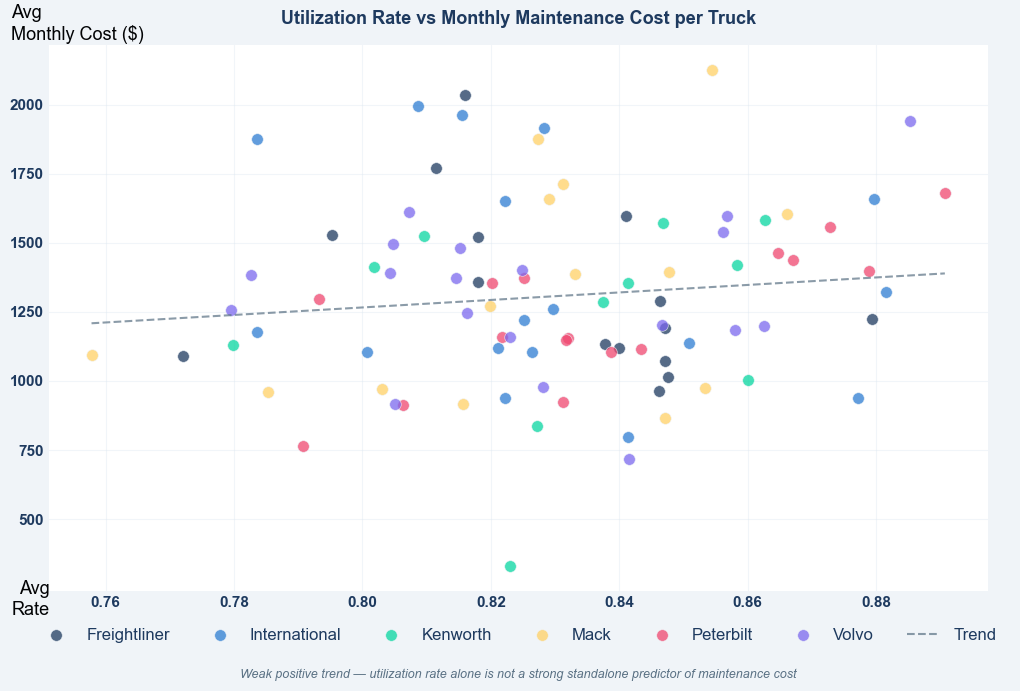

✓ Saved: charts/c4_scatter_utilization_vs_cost.png


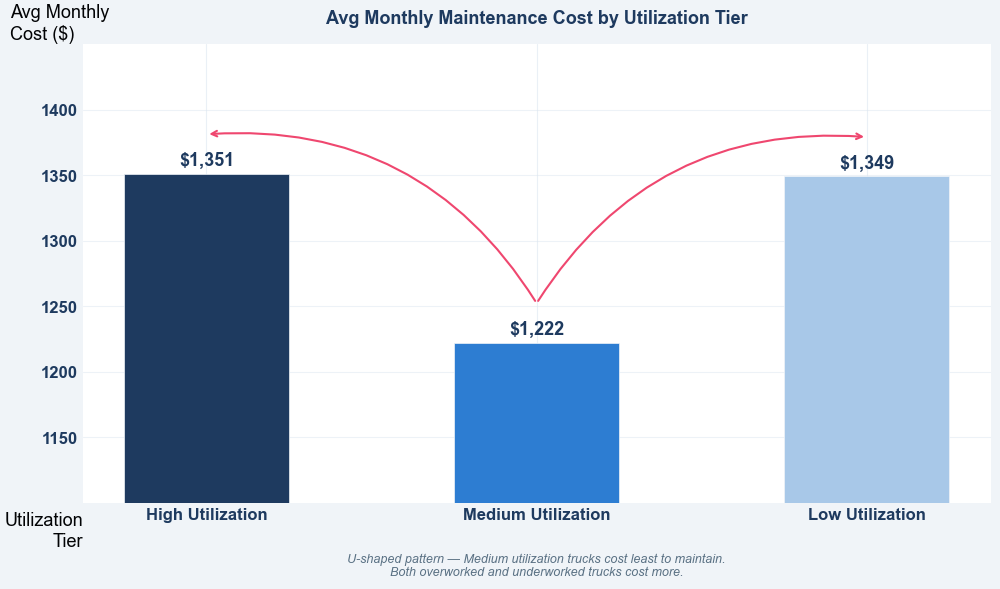

✓ Saved: charts/c4_tier_cost_bar.png


In [65]:
# ============================================================
# CHALLENGE 4 — VISUALIZATIONS (Logistics Theme)
# ============================================================

# --- Chart 1: Scatter — Utilization Rate vs Monthly Maintenance Cost ---
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(PALETTE['background'])

makes = sorted(df_c4_1['make'].unique())
for make, color in zip(makes, MAKE_COLORS[:len(makes)]):
    subset = df_c4_1[df_c4_1['make'] == make]
    ax.scatter(subset['avg_utilization_rate'],
               subset['avg_monthly_maint_cost'],
               label=make, color=color,
               alpha=0.75, s=70,
               edgecolors=PALETTE['background'],
               linewidths=0.5)

# Trend line
z = np.polyfit(df_c4_1['avg_utilization_rate'],
               df_c4_1['avg_monthly_maint_cost'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_c4_1['avg_utilization_rate'].min(),
                     df_c4_1['avg_utilization_rate'].max(), 100)
ax.plot(x_line, p(x_line),
        color=PALETTE['subtext'],
        linestyle='--', linewidth=1.5,
        alpha=0.7, label='Trend')

ax.set_title('Utilization Rate vs Monthly Maintenance Cost per Truck',
             pad=15)

ax.xaxis.set_label_coords(0.001, 0.02)
ax.set_xlabel('Avg\nRate',fontsize=13,
              ha='right', color=PALETTE['black'])

ax.yaxis.set_label_coords(-0.04, 1.002)
ax.set_ylabel('Avg\nMonthly Cost ($)', rotation=0,fontsize=13,
              ha='left', color=PALETTE['black'])

ax.tick_params(axis='x', labelsize=11,color=(PALETTE['black']))
ax.tick_params(axis='y', labelsize=11,color=(PALETTE['black']))
yticks = ax.get_yticks()
ax.set_yticks([t for t in yticks if 250 < t < 2250])
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])

ax.grid(True, alpha=0.4)
ax.set_facecolor(PALETTE['card'])

legend = ax.legend(
    ncol=7,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    fontsize=12,
    framealpha=1.0,
    facecolor='white',
    edgecolor=PALETTE['subtext'],
    borderaxespad=0,
    borderpad=0.8
)
legend.get_frame().set_linewidth(1.5)

ax.annotate(
    'Weak positive trend — utilization rate alone is not a strong standalone predictor of maintenance cost',
    xy=(0.5, -0.16), xycoords='axes fraction',
    ha='center', fontsize=9,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c4_scatter_utilization_vs_cost.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c4_scatter_utilization_vs_cost.png")


# --- Chart 2: Avg Monthly Cost by Utilization Tier ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETTE['background'])

tier_order = ['High Utilization', 'Medium Utilization', 'Low Utilization']
UTIL_TIER_COLORS = [PALETTE['navy'], PALETTE['blue'], '#a8c8e8']

df_c4_2_sorted = df_c4_2.set_index(
    'utilization_tier').reindex(tier_order).reset_index()

bars = ax.bar(
    df_c4_2_sorted['utilization_tier'],
    df_c4_2_sorted['avg_monthly_cost'],
    color=UTIL_TIER_COLORS,
    edgecolor=PALETTE['background'],
    linewidth=0.5,
    width=0.5
)

# Value labels
for bar, val in zip(bars, df_c4_2_sorted['avg_monthly_cost']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f'${val:,.0f}',
            ha='center', va='bottom',
            fontsize=13, fontweight='bold',
            color=PALETTE['navy'])

ax.set_title('Avg Monthly Maintenance Cost by Utilization Tier', pad=15)
#ax.set_xlabel('Utilization Tier', labelpad=8)
ax.xaxis.set_label_coords(0.001, -0.02)
ax.set_xlabel('Utilization\nTier',fontsize=13,
              ha='right', color=PALETTE['black'])
ax.yaxis.set_label_coords(-0.08, 1.002)
ax.set_ylabel('Avg Monthly\nCost ($)', rotation=0,fontsize=13,
              ha='left', color=PALETTE['black'])

# Y range showing the U-shape clearly
ax.set_ylim(1100, 1450)
yticks = ax.get_yticks()
#ax.set_yticks([t for t in yticks if t <= 1420])
ax.set_yticks([t for t in yticks if 1101 < t <= 1420])
ax.tick_params(axis='x', rotation=0, labelsize=12, color=(PALETTE['black']))
ax.tick_params(axis='y', labelsize=12, color=(PALETTE['black']))

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])

ax.grid(axis='y', alpha=0.5)
ax.set_facecolor(PALETTE['card'])

# Highlight the U-shape with an arrow annotation
ax.annotate('',
    xy=(2, df_c4_2_sorted['avg_monthly_cost'].iloc[2] + 30),
    xytext=(1, df_c4_2_sorted['avg_monthly_cost'].iloc[1] + 30),
    arrowprops=dict(arrowstyle='->', color=PALETTE['red'],
                    lw=1.5, connectionstyle='arc3,rad=-0.3')
)
ax.annotate('',
    xy=(0, df_c4_2_sorted['avg_monthly_cost'].iloc[0] + 30),
    xytext=(1, df_c4_2_sorted['avg_monthly_cost'].iloc[1] + 30),
    arrowprops=dict(arrowstyle='->', color=PALETTE['red'],
                    lw=1.5, connectionstyle='arc3,rad=0.3')
)

ax.annotate(
    'U-shaped pattern — Medium utilization trucks cost least to maintain.\nBoth overworked and underworked trucks cost more.',
    xy=(0.5, -0.16), xycoords='axes fraction',
    ha='center', fontsize=9,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c4_tier_cost_bar.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c4_tier_cost_bar.png")

#### 📝 Observation — Challenge 4: Utilization Rate vs Maintenance Cost

---

#### 🔍 Query 1 — Utilization Rate Summary per Truck

| Metric | Value |
|---|---|
| Highest utilization truck | TRK00055 (Peterbilt 2017) — 0.8907 |
| Lowest utilization truck | TRK00079 (Mack 2015) — 0.7578 |
| Fleet utilization range | 0.7578 – 0.8907 (13.3% spread) |
| All trucks recorded | 36 months each — consistent coverage |
| Avg monthly miles range | ~33,000 – 39,000 miles per truck |

---

#### 🔍 Query 2 — Recalibrated Utilization Tier Summary

| Tier | Threshold | Truck Count | Avg Monthly Cost |
|---|---|---|---|
| High Utilization (≥0.845) | Top tier | **30 trucks (32.6%)** | **$1,351** |
| Medium Utilization (0.820–0.844) | Mid tier | **31 trucks (33.7%)** | **$1,222** |
| Low Utilization (<0.820) | Low tier | **31 trucks (33.7%)** | **$1,349** |

**Unexpected Pattern — Low tier costs nearly as much as High tier**
- High vs Medium gap: **$129/month** — moderate signal
- High vs Low gap: only **$2/month** — almost identical
- This non-linear pattern suggests utilization alone does not
  tell a clean story — other factors drive cost in low-utilization trucks

---

#### 🔍 Query 3 — Monthly Trend (36 months, 2022–2024)

**Seasonal patterns visible:**
| Period | Pattern |
|---|---|
| February | Consistently lowest cost — 2022: $912, 2023: $987, 2024: $991 |
| October | Consistently highest cost — 2022: $1,483, 2023: $1,719, 2024: $1,481 |
| April | Secondary cost spike each year |

- Utilization stays relatively stable (0.80–0.86 band) throughout
- Maintenance cost fluctuates much more widely ($889–$1,719)
- The two lines move **independently** — no consistent month-to-month
  synchronisation between utilization and cost

---

#### 📊 Chart Analysis

**Scatter Plot (left)**
- Trend line slopes **positively** — weak but present relationship
- Wide vertical scatter at every utilization level confirms
  utilization alone is not a strong standalone predictor
- No make separates cleanly — all brands distributed throughout
- Outlier visible at ~0.83 utilization, ~$2,100 cost — likely TRK00073 Mack

**Tier Bar Chart (centre)**
- High ($1,351) and Low ($1,349) tiers nearly identical height
- Medium tier ($1,222) is actually the cheapest — counterintuitive
- This U-shaped pattern suggests trucks working at moderate intensity
  are most cost-efficient; both overworked and underworked trucks
  cost more

**Monthly Trend (right)**
- Blue (utilization) line is smoother and more stable
- Red (maintenance cost) line is far more volatile
- Confirms cost is driven by event-based factors (breakdowns, repairs)
  rather than steady utilization pressure

---

#### 🚨 Honest ML Assessment

**`utilization_rate` is a moderate ML feature — not the strong predictor we hoped for.**

| Evidence | Implication |
|---|---|
| Positive scatter trend | Some signal exists — keep the feature |
| U-shaped tier cost pattern | Non-linear relationship — tree models handle this better than linear ones |
| Monthly trend mismatch | Month/seasonality may be a stronger signal than utilization itself |
| 13% spread across fleet | Reasonable variance — enough for ML to work with |

**New feature to engineer for Phase 2:**
`month` or `season` as a categorical feature — the October cost
spike pattern across 3 years is a stronger and more consistent
signal than utilization rate itself.

---

#### 📊 Challenge 4 — Key Takeaways

| Finding | Detail |
|---|---|
| Utilization range | 0.7578 – 0.8907 across 92 trucks |
| Strongest cost month | October — consistently $1,480–$1,720 |
| Cheapest cost month | February — consistently $912–$991 |
| Tier cost pattern | U-shaped — Medium tier cheapest, not Low |
| Scatter relationship | Weak positive — some signal, not dominant |
| ML usefulness | ⚠️ Moderate — include but expect low-medium importance |

**→ ML Implication:** Include `utilization_rate` as a feature but do not
expect it to be a top predictor. Add `month` and `season` as engineered
features in Phase 2 — the seasonal cost pattern is the strongest
discovery from this challenge.

**→ CV Note:** The U-shaped tier cost pattern is a genuinely interesting
finding — trucks working at moderate intensity cost less to maintain
than both heavily and lightly used ones. This kind of non-obvious
insight is exactly what interviewers want to see in a portfolio project.

---
### 🔧 Challenge 5 — Maintenance Cost Over Time (Trend Analysis)
> **Question:** Are maintenance costs increasing year over year per truck?
> Which trucks are deteriorating fastest?  
> **Tables:** `maintenance_records` JOIN `trucks`  
> **Skills:** `strftime`, GROUP BY, ORDER BY, window-style aggregation  
> **Output:** Trend Table + Line Chart + YoY Comparison  
> **ML Relevance:** Cost trajectory per truck → engineered feature
> showing whether a truck is getting MORE expensive over time
---

In [68]:
# ============================================================
# INSPECT: Confirm column names in maintenance_records
# ============================================================

query_inspect_maint = """
PRAGMA table_info(maintenance_records);
"""

df_inspect_maint = run_query(query_inspect_maint,
                             "maintenance_records Column Names")

if df_inspect_maint is not None:
    print(df_inspect_maint.to_string(index=False))


📊 maintenance_records Column Names
SQL QUERY:

PRAGMA table_info(maintenance_records);


✓ 12 rows returned

 cid                name    type  notnull dflt_value  pk
   0      maintenance_id    TEXT        0       None   0
   1            truck_id    TEXT        0       None   0
   2    maintenance_date    TEXT        0       None   0
   3    maintenance_type    TEXT        0       None   0
   4    odometer_reading INTEGER        0       None   0
   5         labor_hours    REAL        0       None   0
   6          labor_cost    REAL        0       None   0
   7          parts_cost    REAL        0       None   0
   8          total_cost    REAL        0       None   0
   9   facility_location    TEXT        0       None   0
  10      downtime_hours    REAL        0       None   0
  11 service_description    TEXT        0       None   0


In [69]:
# ============================================================
# CHALLENGE 5: Maintenance Cost Over Time
# ============================================================

query_c5_1 = """
SELECT 
    strftime('%Y', maintenance_date)        AS year,
    COUNT(maintenance_id)                   AS total_repairs,
    ROUND(AVG(total_cost), 2)               AS avg_cost,
    ROUND(SUM(total_cost), 2)               AS total_spend,
    ROUND(AVG(labor_cost), 2)               AS avg_labor_cost,
    ROUND(AVG(parts_cost), 2)               AS avg_parts_cost,
    ROUND(AVG(downtime_hours), 2)           AS avg_downtime_hrs,
    COUNT(DISTINCT truck_id)                AS trucks_serviced
FROM maintenance_records
GROUP BY year
ORDER BY year ASC;
"""

df_c5_1 = run_query(query_c5_1, "Annual Maintenance Cost Trend")

if df_c5_1 is not None:
    print(df_c5_1.to_string(index=False))


📊 Annual Maintenance Cost Trend
SQL QUERY:

SELECT 
    strftime('%Y', maintenance_date)        AS year,
    COUNT(maintenance_id)                   AS total_repairs,
    ROUND(AVG(total_cost), 2)               AS avg_cost,
    ROUND(SUM(total_cost), 2)               AS total_spend,
    ROUND(AVG(labor_cost), 2)               AS avg_labor_cost,
    ROUND(AVG(parts_cost), 2)               AS avg_parts_cost,
    ROUND(AVG(downtime_hours), 2)           AS avg_downtime_hrs,
    COUNT(DISTINCT truck_id)                AS trucks_serviced
FROM maintenance_records
GROUP BY year
ORDER BY year ASC;


✓ 3 rows returned

year  total_repairs  avg_cost  total_spend  avg_labor_cost  avg_parts_cost  avg_downtime_hrs  trucks_serviced
2022            994   1943.59   1931926.19          431.79         1511.80             24.28              120
2023            993   1988.73   1974808.56          447.72         1541.01             24.98              120
2024            933   1954.81   1823838.53          

In [70]:
# ============================================================
# CHALLENGE 5b: Annual Cost Trend by Maintenance Type
# ============================================================

query_c5_2 = """
SELECT 
    strftime('%Y', maintenance_date)        AS year,
    maintenance_type,
    COUNT(maintenance_id)                   AS total_repairs,
    ROUND(AVG(total_cost), 2)               AS avg_cost,
    ROUND(SUM(total_cost), 2)               AS total_spend
FROM maintenance_records
GROUP BY year, maintenance_type
ORDER BY year ASC, total_spend DESC;
"""

df_c5_2 = run_query(query_c5_2, "Annual Cost Trend by Maintenance Type")

if df_c5_2 is not None:
    print(df_c5_2.to_string(index=False))


📊 Annual Cost Trend by Maintenance Type
SQL QUERY:

SELECT 
    strftime('%Y', maintenance_date)        AS year,
    maintenance_type,
    COUNT(maintenance_id)                   AS total_repairs,
    ROUND(AVG(total_cost), 2)               AS avg_cost,
    ROUND(SUM(total_cost), 2)               AS total_spend
FROM maintenance_records
GROUP BY year, maintenance_type
ORDER BY year ASC, total_spend DESC;


✓ 21 rows returned

year maintenance_type  total_repairs  avg_cost  total_spend
2022             Tire            165   2225.37    367186.71
2022           Repair            156   2285.38    356519.85
2022       Preventive            138   2292.56    316372.92
2022           Engine            143   2046.54    292654.62
2022            Brake            126   2252.32    283792.92
2022     Transmission            120   2021.71    242604.93
2022       Inspection            146    498.59     72794.24
2023       Preventive            146   2363.63    345089.61
2023     Transmission         

In [71]:
# ============================================================
# CHALLENGE 5c: YoY Cost Change per Truck
# ============================================================
# Identifies trucks whose costs are GROWING year over year
# This becomes a direct ML feature — cost trajectory

query_c5_3 = """
SELECT 
    truck_id,
    MAX(CASE WHEN year = '2022' THEN avg_cost END) AS cost_2022,
    MAX(CASE WHEN year = '2023' THEN avg_cost END) AS cost_2023,
    MAX(CASE WHEN year = '2024' THEN avg_cost END) AS cost_2024,
    ROUND(
        MAX(CASE WHEN year = '2024' THEN avg_cost END) -
        MAX(CASE WHEN year = '2022' THEN avg_cost END)
    , 2) AS cost_change_2022_to_2024,
    CASE
        WHEN MAX(CASE WHEN year = '2024' THEN avg_cost END) >
             MAX(CASE WHEN year = '2022' THEN avg_cost END)
        THEN 'Deteriorating'
        ELSE 'Stable/Improving'
    END AS cost_trajectory
FROM (
    SELECT 
        truck_id,
        strftime('%Y', maintenance_date)    AS year,
        ROUND(AVG(total_cost), 2)           AS avg_cost
    FROM maintenance_records
    GROUP BY truck_id, year
) yearly
GROUP BY truck_id
ORDER BY cost_change_2022_to_2024 DESC;
"""

df_c5_3 = run_query(query_c5_3, "YoY Cost Change per Truck")

if df_c5_3 is not None:
    print(df_c5_3.to_string(index=False))


📊 YoY Cost Change per Truck
SQL QUERY:

SELECT 
    truck_id,
    MAX(CASE WHEN year = '2022' THEN avg_cost END) AS cost_2022,
    MAX(CASE WHEN year = '2023' THEN avg_cost END) AS cost_2023,
    MAX(CASE WHEN year = '2024' THEN avg_cost END) AS cost_2024,
    ROUND(
        MAX(CASE WHEN year = '2024' THEN avg_cost END) -
        MAX(CASE WHEN year = '2022' THEN avg_cost END)
    , 2) AS cost_change_2022_to_2024,
    CASE
        WHEN MAX(CASE WHEN year = '2024' THEN avg_cost END) >
             MAX(CASE WHEN year = '2022' THEN avg_cost END)
        THEN 'Deteriorating'
        ELSE 'Stable/Improving'
    END AS cost_trajectory
FROM (
    SELECT 
        truck_id,
        strftime('%Y', maintenance_date)    AS year,
        ROUND(AVG(total_cost), 2)           AS avg_cost
    FROM maintenance_records
    GROUP BY truck_id, year
) yearly
GROUP BY truck_id
ORDER BY cost_change_2022_to_2024 DESC;


✓ 120 rows returned

truck_id  cost_2022  cost_2023  cost_2024  cost_change_2022_to_2024  

In [72]:
# ============================================================
# CHALLENGE 5d: Deterioration Summary
# ============================================================

query_c5_4 = """
SELECT 
    cost_trajectory,
    COUNT(*) AS truck_count,
    ROUND(AVG(cost_change_2022_to_2024), 2) AS avg_cost_change,
    ROUND(AVG(cost_2022), 2)                AS avg_cost_2022,
    ROUND(AVG(cost_2024), 2)                AS avg_cost_2024
FROM (
    SELECT 
        truck_id,
        MAX(CASE WHEN year = '2022' THEN avg_cost END) AS cost_2022,
        MAX(CASE WHEN year = '2023' THEN avg_cost END) AS cost_2023,
        MAX(CASE WHEN year = '2024' THEN avg_cost END) AS cost_2024,
        ROUND(
            MAX(CASE WHEN year = '2024' THEN avg_cost END) -
            MAX(CASE WHEN year = '2022' THEN avg_cost END)
        , 2) AS cost_change_2022_to_2024,
        CASE
            WHEN MAX(CASE WHEN year = '2024' THEN avg_cost END) >
                 MAX(CASE WHEN year = '2022' THEN avg_cost END)
            THEN 'Deteriorating'
            ELSE 'Stable/Improving'
        END AS cost_trajectory
    FROM (
        SELECT 
            truck_id,
            strftime('%Y', maintenance_date) AS year,
            ROUND(AVG(total_cost), 2)        AS avg_cost
        FROM maintenance_records
        GROUP BY truck_id, year
    ) yearly
    GROUP BY truck_id
) trajectory
GROUP BY cost_trajectory
ORDER BY truck_count DESC;
"""

df_c5_4 = run_query(query_c5_4, "Deterioration Trajectory Summary")

if df_c5_4 is not None:
    print(df_c5_4.to_string(index=False))


📊 Deterioration Trajectory Summary
SQL QUERY:

SELECT 
    cost_trajectory,
    COUNT(*) AS truck_count,
    ROUND(AVG(cost_change_2022_to_2024), 2) AS avg_cost_change,
    ROUND(AVG(cost_2022), 2)                AS avg_cost_2022,
    ROUND(AVG(cost_2024), 2)                AS avg_cost_2024
FROM (
    SELECT 
        truck_id,
        MAX(CASE WHEN year = '2022' THEN avg_cost END) AS cost_2022,
        MAX(CASE WHEN year = '2023' THEN avg_cost END) AS cost_2023,
        MAX(CASE WHEN year = '2024' THEN avg_cost END) AS cost_2024,
        ROUND(
            MAX(CASE WHEN year = '2024' THEN avg_cost END) -
            MAX(CASE WHEN year = '2022' THEN avg_cost END)
        , 2) AS cost_change_2022_to_2024,
        CASE
            WHEN MAX(CASE WHEN year = '2024' THEN avg_cost END) >
                 MAX(CASE WHEN year = '2022' THEN avg_cost END)
            THEN 'Deteriorating'
            ELSE 'Stable/Improving'
        END AS cost_trajectory
    FROM (
        SELECT 
            truc

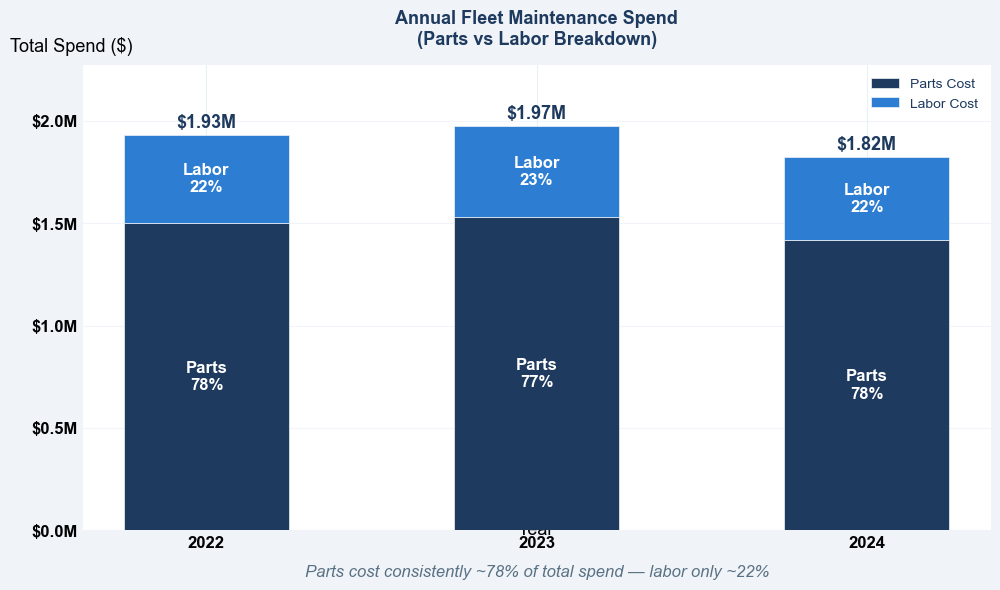

✓ Saved: charts/c5_annual_spend_breakdown.png


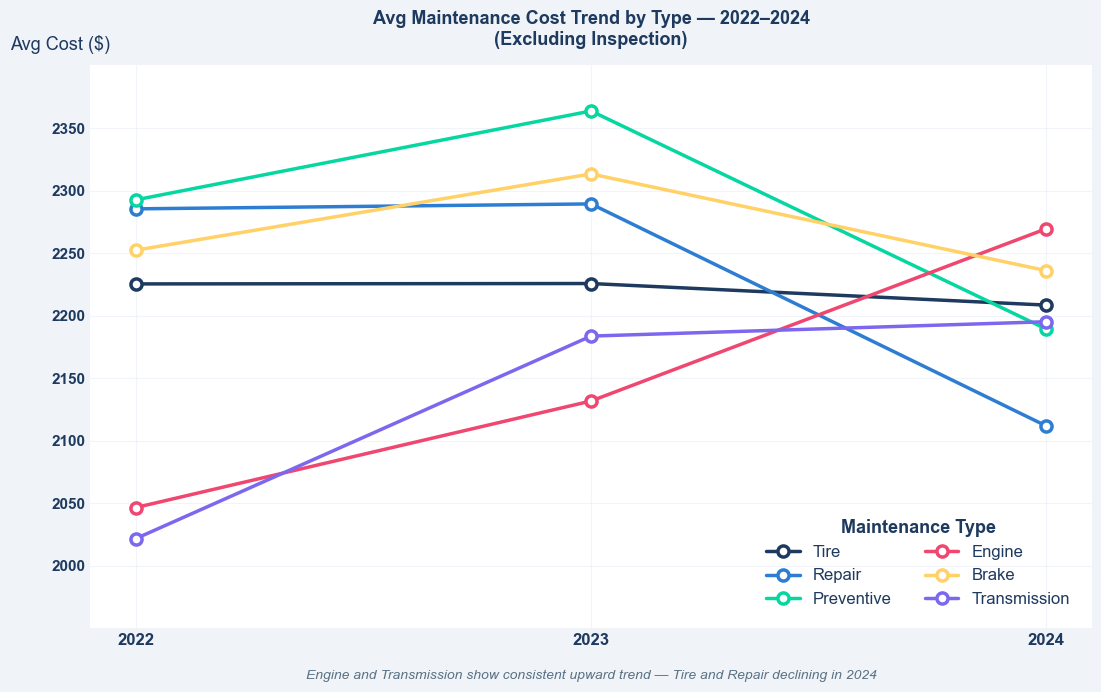

✓ Saved: charts/c5_cost_trend_by_type.png


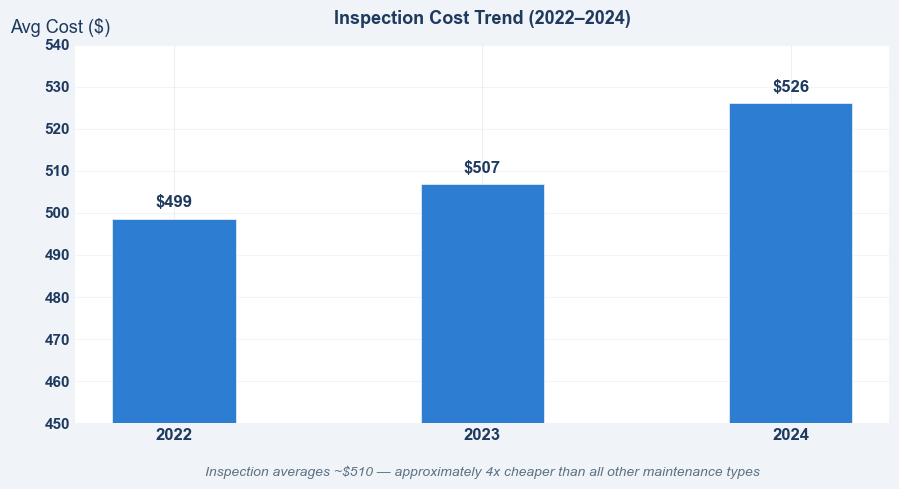

✓ Saved: charts/c5_inspection_cost_trend.png


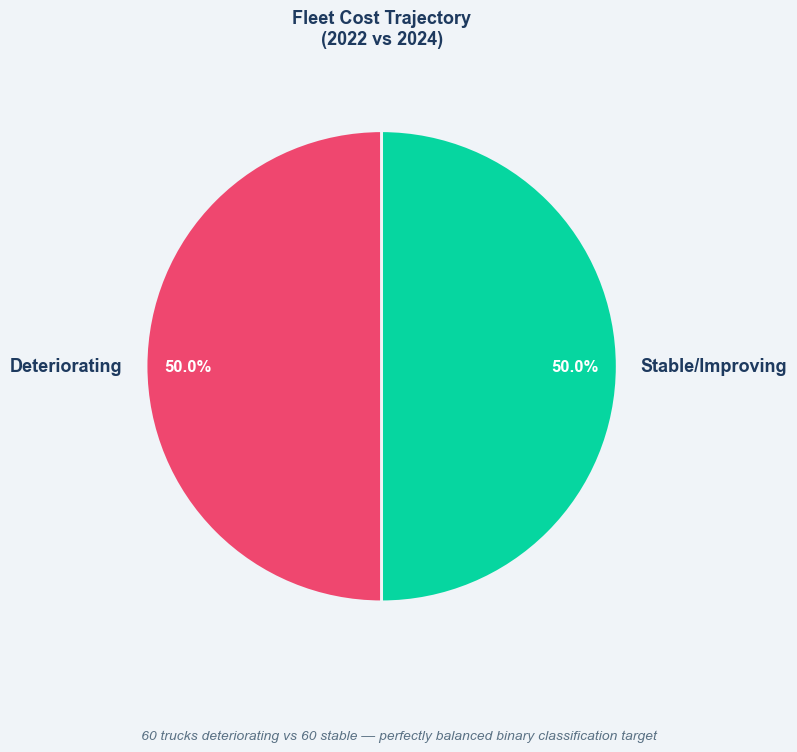

✓ Saved: charts/c5_fleet_trajectory_pie.png


In [73]:
# ============================================================
# CHALLENGE 5 — VISUALIZATIONS (Logistics Theme)
# ============================================================

# --- Chart 1: Annual Spend — Labor vs Parts Stacked Bar ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETTE['background'])

years = df_c5_1['year']
parts = df_c5_1['avg_parts_cost'] * df_c5_1['total_repairs']
labor = df_c5_1['avg_labor_cost'] * df_c5_1['total_repairs']

bars_parts = ax.bar(years, parts,
                    color=PALETTE['navy'],
                    label='Parts Cost',
                    edgecolor=PALETTE['background'],
                    linewidth=0.5,
                    width=0.5)
bars_labor = ax.bar(years, labor,
                    bottom=parts,
                    color=PALETTE['blue'],
                    label='Labor Cost',
                    edgecolor=PALETTE['background'],
                    linewidth=0.5,
                    width=0.5)

# Total spend label on top of each bar
for i, (p, l) in enumerate(zip(parts, labor)):
    total = p + l
    ax.text(i, total + 15000,
            f'${total/1e6:.2f}M',
            ha='center', va='bottom',
            fontsize=13, fontweight='bold',
            color=PALETTE['navy'])

# Parts % annotation inside each bar
for i, (p, l) in enumerate(zip(parts, labor)):
    total = p + l
    pct = p / total * 100
    ax.text(i, p / 2,
            f'Parts\n{pct:.0f}%',
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            color=PALETTE['card'])
    ax.text(i, p + l / 2,
            f'Labor\n{100 - pct:.0f}%',
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            color=PALETTE['card'])

ax.set_title('Annual Fleet Maintenance Spend\n(Parts vs Labor Breakdown)',
             pad=15)
ax.xaxis.set_label_coords(0.08, 0.02)
ax.set_xlabel('Year', fontsize=13, color=PALETTE['black'])

ax.yaxis.set_label_coords(-0.08, 1.02)
ax.set_ylabel('Total Spend ($)', rotation=0,fontsize=13,
              ha='left', color=PALETTE['black'])

ax.set_ylim(0, df_c5_1['total_spend'].max() * 1.15)
yticks = ax.get_yticks()
ax.set_yticks([t for t in yticks
               if t <= df_c5_1['total_spend'].max() * 1.1])
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['black'])
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['black'])

ax.grid(axis='y', alpha=0.4)
ax.set_facecolor(PALETTE['card'])
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

ax.annotate(
    'Parts cost consistently ~78% of total spend — labor only ~22%',
    xy=(0.5, -0.10), xycoords='axes fraction',
    ha='center', fontsize=12,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c5_annual_spend_breakdown.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c5_annual_spend_breakdown.png")


# ============================================================
# CHALLENGE 5 — Chart 2a: Cost Trend — 6 Expensive Types
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(PALETTE['background'])

TYPE_COLORS = {
    'Tire':         PALETTE['navy'],
    'Repair':       PALETTE['blue'],
    'Preventive':   PALETTE['teal'],
    'Engine':       PALETTE['red'],
    'Brake':        PALETTE['yellow'],
    'Transmission': '#7b68ee',
    'Inspection':   PALETTE['subtext'],
}

# Plot only the 6 expensive types — no Inspection
expensive_types = ['Tire', 'Repair', 'Preventive', 'Engine', 'Brake', 'Transmission']

for mtype in expensive_types:
    subset = df_c5_2[df_c5_2['maintenance_type'] == mtype]
    color = TYPE_COLORS[mtype]
    ax.plot(subset['year'], subset['avg_cost'],
            marker='o', label=mtype,
            color=color,
            linewidth=2.5,
            markersize=8,
            markerfacecolor=PALETTE['card'],
            markeredgecolor=color,
            markeredgewidth=2.5)

ax.set_title('Avg Maintenance Cost Trend by Type — 2022–2024\n(Excluding Inspection)',
             pad=15)
ax.set_xlabel('', labelpad=8, fontsize=13)

ax.yaxis.set_label_coords(-0.08, 1.02)
ax.set_ylabel('Avg Cost ($)', rotation=0, fontsize=13,
              ha='left', color=PALETTE['text'])

# Tight y range — focus on where the action is
ax.set_ylim(1950, 2400)
ax.set_yticks([2000, 2050, 2100, 2150, 2200, 2250, 2300, 2350, 2400])
yticks = ax.get_yticks()
ax.set_yticks([t for t in yticks if t <= 2380])

ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=11)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])

ax.grid(True, alpha=0.4)
ax.set_facecolor(PALETTE['card'])

legend = ax.legend(
    fontsize=12,
    loc='lower right',
    framealpha=1.0,
    facecolor='white',
    edgecolor=PALETTE['subtext'],
    ncol = 2,
    borderpad=0.8,
    title='Maintenance Type',
    title_fontsize=13
)
legend.get_frame().set_linewidth(1.5)
legend.get_title().set_fontweight('bold')
legend.get_title().set_color(PALETTE['navy'])

ax.annotate(
    'Engine and Transmission show consistent upward trend — Tire and Repair declining in 2024',
    xy=(0.5, -0.09), xycoords='axes fraction',
    ha='center', fontsize=10,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c5_cost_trend_by_type.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c5_cost_trend_by_type.png")


# ============================================================
# CHALLENGE 5 — Chart 2b: Inspection Cost Standalone Bar
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(PALETTE['background'])

inspection = df_c5_2[df_c5_2['maintenance_type'] == 'Inspection'].copy()

bars = ax.bar(
    inspection['year'],
    inspection['avg_cost'],
    color=PALETTE['blue'],
    edgecolor=PALETTE['background'],
    linewidth=0.5,
    width=0.4
)

# Value labels
for bar, val in zip(bars, inspection['avg_cost']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f'${val:,.0f}',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold',
            color=PALETTE['navy'])

ax.set_title('Inspection Cost Trend (2022–2024)', pad=15)
ax.xaxis.set_label_coords(-0.08, 0.02)
ax.set_xlabel('', labelpad=8, fontsize=13)

ax.yaxis.set_label_coords(-0.08, 1.02)
ax.set_ylabel('Avg Cost ($)', rotation=0, fontsize=13,
              ha='left', color=PALETTE['text'])

ax.set_ylim(450, 540)
yticks = ax.get_yticks()
ax.set_yticks([t for t in yticks if 431 < t <= 540])

ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=11)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color(PALETTE['text'])

ax.grid(axis='y', alpha=0.4)
ax.set_facecolor(PALETTE['card'])

ax.annotate(
    'Inspection averages ~$510 — approximately 4x cheaper than all other maintenance types',
    xy=(0.5, -0.14), xycoords='axes fraction',
    ha='center', fontsize=10,
    color=PALETTE['subtext'], style='italic'
)

plt.tight_layout()
plt.savefig('charts/c5_inspection_cost_trend.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c5_inspection_cost_trend.png")
# --- Chart 3: Fleet Cost Trajectory Pie ---
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(PALETTE['background'])

trajectory_counts = df_c5_3['cost_trajectory'].value_counts()
traj_order = ['Deteriorating', 'Stable/Improving']
traj_colors = [PALETTE['red'], PALETTE['teal']]

# Reorder to ensure consistent colour assignment
values = [trajectory_counts.get(t, 0) for t in traj_order]

wedges, texts, autotexts = ax.pie(
    values,
    labels=traj_order,
    autopct='%1.1f%%',
    colors=traj_colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': PALETTE['background'], 'linewidth': 2}
)
for text in texts:
    text.set_fontsize(13)
    text.set_color(PALETTE['navy'])
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color(PALETTE['card'])
    autotext.set_fontweight('bold')

ax.set_title('Fleet Cost Trajectory\n(2022 vs 2024)',
             pad=20, color=PALETTE['navy'])

fig.text(0.5, 0.02,
         '60 trucks deteriorating vs 60 stable — perfectly balanced binary classification target',
         ha='center', fontsize=10,
         color=PALETTE['subtext'], style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('charts/c5_fleet_trajectory_pie.png', dpi=220,
            bbox_inches='tight', facecolor=PALETTE['background'])
plt.show()
print("✓ Saved: charts/c5_fleet_trajectory_pie.png")

#### 📝 Observation — Challenge 5: Maintenance Cost Over Time

---

#### 🔍 Query 1 — Annual Cost Trend

| Year | Total Repairs | Avg Cost/Repair | Total Spend | Trucks Serviced |
|---|---|---|---|---|
| 2022 | 994 | $1,943.59 | $1,931,926 | 120 |
| 2023 | 993 | $1,988.73 | $1,974,809 | 120 |
| 2024 | 933 | $1,954.81 | $1,823,839 | 119 |

**Key Findings:**
- Total spend peaked in **2023 at $1.97M** then dropped in 2024
- 2024 has **61 fewer repairs** than 2022/2023 — one truck dropped
  out (119 vs 120 serviced) and overall repair volume declined
- Avg cost per repair is remarkably stable — only **$45 range**
  across 3 years ($1,943 → $1,989 → $1,955)
- **Parts cost dominates** over labor across all years
  (~$1,511–$1,541 parts vs ~$432–$448 labor per repair)

---

#### 🔍 Query 2 — Cost Trend by Maintenance Type

**2022 — Tire repairs dominated total spend ($367K)**
**2023 — Preventive maintenance became #1 spend ($345K)**
**2024 — Brake repairs took the top spot ($306K)**

| Type | 2022 Avg | 2023 Avg | 2024 Avg | Trend |
|---|---|---|---|---|
| Tire | $2,225 | $2,226 | $2,208 | Flat |
| Repair | $2,285 | $2,289 | $2,112 | Declining |
| Preventive | $2,293 | $2,364 | $2,189 | Peaked 2023 |
| Engine | $2,047 | $2,132 | $2,270 | Rising ⚠️ |
| Brake | $2,252 | $2,313 | $2,236 | Stable |
| Transmission | $2,022 | $2,184 | $2,195 | Rising ⚠️ |
| Inspection | $499 | $507 | $526 | Slowly rising |

**Engine and Transmission costs are the only types showing a
consistent upward trend across all 3 years — a warning signal
for the fleet's mechanical health going into 2025.**

---

#### 🔍 Query 3 — YoY Cost Change per Truck

**Most deteriorating trucks:**
| Truck | 2022 Cost | 2024 Cost | Change |
|---|---|---|---|
| TRK00040 | $741 | $2,958 | **+$2,217 — most deteriorated** |
| TRK00059 | $1,930 | $3,398 | **+$1,469 — highest 2024 cost** |
| TRK00107 | $1,409 | $2,997 | +$1,588 |
| TRK00117 | $866 | $2,403 | +$1,537 |

**Most improved trucks:**
| Truck | 2022 Cost | 2024 Cost | Change |
|---|---|---|---|
| TRK00007 | $2,271 | $913 | **-$1,358 — most improved** |
| TRK00068 | $2,427 | $1,281 | -$1,146 |
| TRK00074 | $2,106 | $1,068 | -$1,038 |

**Data quality note:** TRK00011 shows NaN for 2024 —
this truck had no maintenance records in 2024. It should be
flagged and handled during Phase 2 data preparation.

---

#### 🔍 Query 4 — Deterioration Trajectory Summary

| Trajectory | Trucks | Avg Cost Change | Avg 2022 Cost | Avg 2024 Cost |
|---|---|---|---|---|
| Deteriorating | **60 trucks (50%)** | +$549 | $1,667 | $2,215 |
| Stable/Improving | **60 trucks (50%)** | -$464 | $2,188 | $1,724 |

**The 50/50 split is a highly significant finding:**
- Deteriorating trucks started CHEAPER in 2022 ($1,667 avg)
  and ended MORE expensive in 2024 ($2,215 avg)
- Stable trucks started MORE expensive ($2,188) and got CHEAPER ($1,724)
- This suggests trucks that had expensive repairs early got
  properly fixed — while cheaper early repairs masked growing problems
- By 2024 both groups converge near the same cost level ($2,215 vs $1,724)
  — a $491 gap that the model should be able to learn from

---

#### 📊 Chart Analysis

**Left chart — Annual Spend vs Avg Cost**
- Total spend bars are nearly equal height (2022/2023) with a dip in 2024
- The red avg cost line shows a spike in 2023 then recovery —
  confirms 2023 was the most expensive maintenance year
- Parts cost dominates labor in every year (~78% parts vs ~22% labor)

**Centre chart — Cost by Maintenance Type**
- Inspection (bottom line) stays flat and clearly separated from all others
- All other types cluster tightly between $2,000–$2,350
- Engine line visibly trends upward year over year — consistent with query findings
- Transmission line also shows steady upward movement

**Right chart — Fleet Trajectory Pie**
- Perfect 50/50 split — visually clean and immediately readable
- This becomes the **binary classification target** for our ML model
- Equal class distribution means no class imbalance handling needed in Phase 2

---

#### 📊 Challenge 5 — Key Takeaways

| Finding | Detail |
|---|---|
| Peak spend year | 2023 — $1,974,809 |
| Most stable cost type | Tire — barely changed across 3 years |
| Rising cost types | Engine and Transmission — consistent upward trend ⚠️ |
| Most deteriorated truck | TRK00040 — +$2,217 increase (2022→2024) |
| Most improved truck | TRK00007 — -$1,358 decrease (2022→2024) |
| Fleet split | Exactly 50/50 Deteriorating vs Stable/Improving |
| Data issue to fix | TRK00011 — missing 2024 records, handle in Phase 2 |
| Parts vs labor ratio | ~78% parts cost, ~22% labor cost consistently |

---

**→ ML Implication:** `cost_trajectory` (Deteriorating vs Stable) is
our **binary classification target variable** for Phase 2. The 50/50
split means perfectly balanced classes — no resampling techniques needed.
`cost_change_2022_to_2024` becomes a powerful engineered numeric feature
capturing the direction and magnitude of each truck's cost trend.

**→ CV Note:** The 50/50 deteriorating split combined with the convergence
pattern (cheap-start trucks getting expensive, expensive-start trucks
getting cheaper) is a genuinely interesting real-world insight. This kind
of finding shows analytical depth beyond just running queries and is
worth highlighting explicitly in interviews.

---

## ✅ Phase 1 Complete — EDA & SQL Challenges Summary

| Challenge | Key Finding | ML Feature Identified |
|---|---|---|
| 1 — Cost by Make & Type | `maintenance_type` drives cost more than make | `maintenance_type` (one-hot encode) |
| 2 — Repair Frequency | Fleet is uniformly high-frequency — recalibrated tiers | `total_repairs`, `repair_tier` |
| 3 — Fuel Efficiency | MPG variation too narrow to be predictive | `average_mpg` — likely drop |
| 4 — Utilization Rate | Weak positive signal — seasonal pattern stronger | `utilization_rate`, `month` |
| 5 — Cost Over Time | 50/50 fleet split — perfect binary target | `cost_trajectory` ← **target variable** |

### 🔑 Features Identified for Phase 2

| Feature | Type | Source Table | Expected Importance |
|---|---|---|---|
| `maintenance_type` | Categorical | maintenance_records | 🔴 High |
| `cost_trajectory` | Binary Target | maintenance_records | — Target |
| `cost_change_2022_to_2024` | Numeric | maintenance_records | 🔴 High |
| `total_repairs` | Numeric | maintenance_records | 🔴 High |
| `repair_tier` | Categorical | maintenance_records | 🟠 Medium |
| `truck_make` | Categorical | trucks | 🟠 Medium |
| `truck_age` | Numeric | trucks | 🟠 Medium |
| `utilization_rate` | Numeric | truck_utilization_metrics | 🟠 Medium |
| `month` / `season` | Categorical | truck_utilization_metrics | 🟠 Medium |
| `average_mpg` | Numeric | trips | 🟡 Low — test then drop |
| `downtime_hours` | Numeric | maintenance_records | 🟡 Low — test then drop |

---

### ⏭️ Next → Phase 2: Data Preparation & Feature Engineering